<a href="https://colab.research.google.com/github/jmoralespineda/TEORIA_DE_SE-ALES/blob/main/TALLER_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Julian David Morales Pineda

#**1. Generacion de señal binaria**

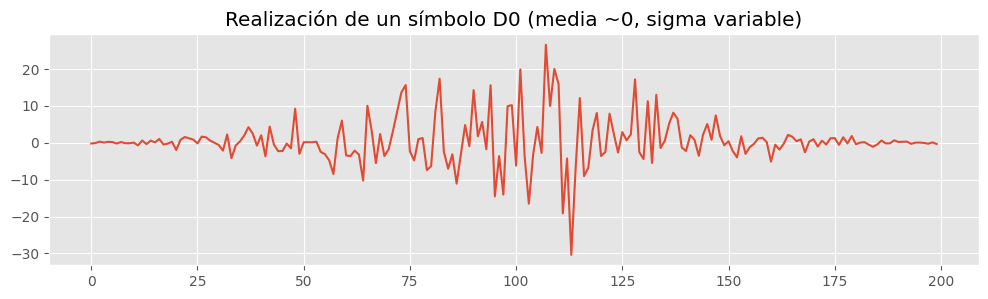

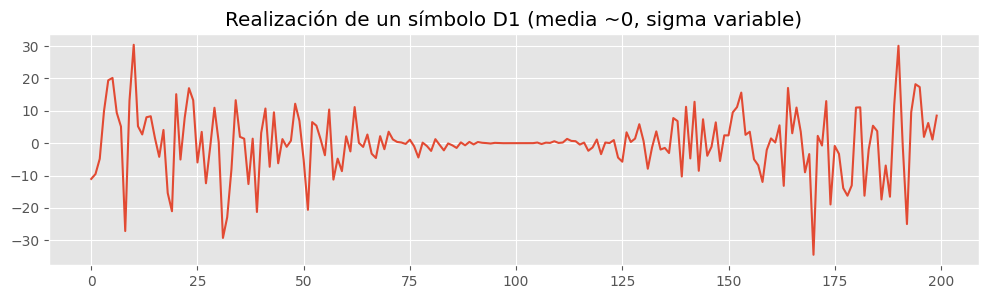

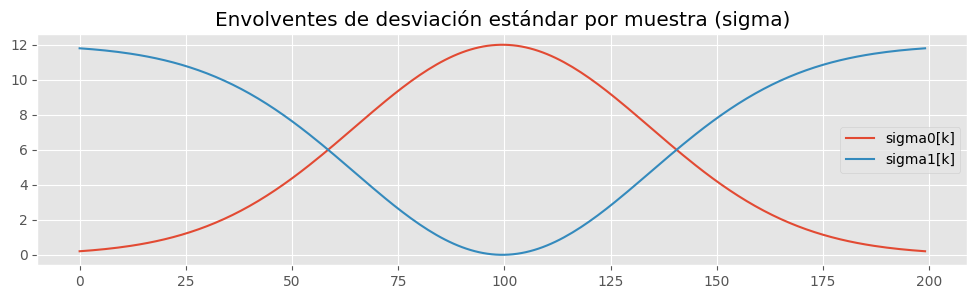

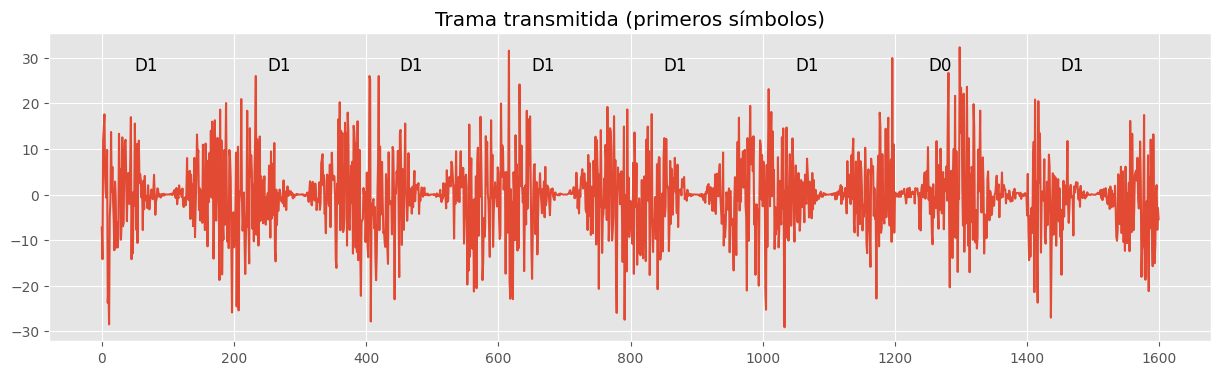

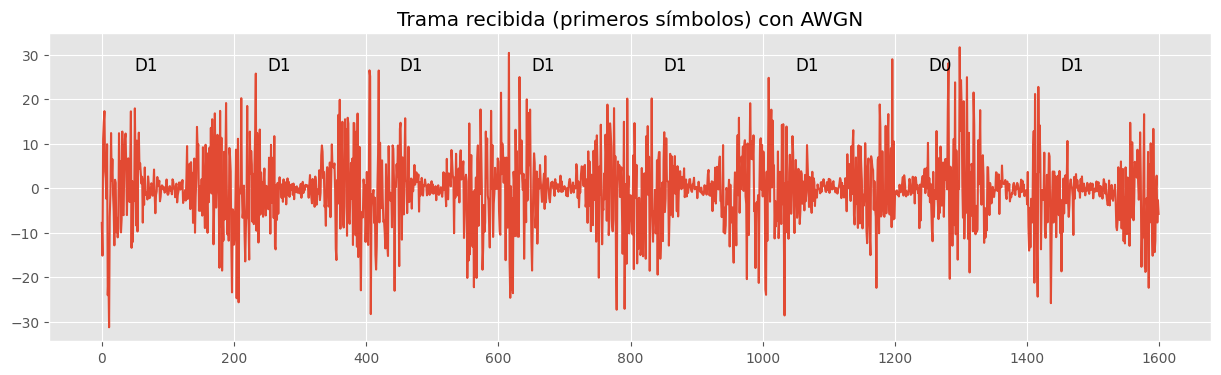

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

# ============================================================
# PARÁMETROS
# ============================================================
Ns = 200
Nsymbols = 1024
Nview = 8

sigma_max = 12.0
epsilon = 1e-3
A0 = 1.0
A1 = 1.0

noise_sigma = 1.0   # AWGN del canal (se suma a la señal transmitida)

# Reproducibilidad para depuración (cambia a None cuando hagas Monte Carlo)
seed = 123
rng = np.random.default_rng(seed)

assert Nview <= Nsymbols

# ============================================================
# ENVOLVENTES (NOTA: SON SIGMAS, NO VARIANZAS)
# ============================================================
def generar_sigmas(Ns, sigma_max, sigma_env=0.35):
    t = np.linspace(-1, 1, Ns)
    g = np.exp(-(t**2) / (2 * sigma_env**2))
    sigma0 = sigma_max * g
    sigma1 = sigma_max * (1 - g)
    return sigma0, sigma1

sigma0_t, sigma1_t = generar_sigmas(Ns, sigma_max)

# Clampeo por estabilidad numérica (evita sigma=0 exacto)
sigma0_use = np.maximum(sigma0_t, epsilon)
sigma1_use = np.maximum(sigma1_t, epsilon)

# ============================================================
# GENERACIÓN DE SÍMBOLO (realización aleatoria Gaussiana, media 0)
# ============================================================
def generar_simbolo(bit, rng):
    z = rng.standard_normal(Ns)  # N(0,1)
    if bit == 0:
        return A0 * (z * sigma0_use)
    else:
        return A1 * (z * sigma1_use)

# ============================================================
# VISUALIZACIONES BÁSICAS (una realización + envolventes)
# ============================================================
plt.figure(figsize=(12,3))
plt.plot(generar_simbolo(0, rng))
plt.title("Realización de un símbolo D0 (media ~0, sigma variable)")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,3))
plt.plot(generar_simbolo(1, rng))
plt.title("Realización de un símbolo D1 (media ~0, sigma variable)")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,3))
plt.plot(sigma0_use, label="sigma0[k]")
plt.plot(sigma1_use, label="sigma1[k]")
plt.title("Envolventes de desviación estándar por muestra (sigma)")
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# TRAMA TRANSMITIDA (MATRIZ POR SÍMBOLO) + CANAL AWGN
# ============================================================
bits = rng.integers(0, 2, Nsymbols)

tx_matrix = np.zeros((Nsymbols, Ns))
for i, b in enumerate(bits):
    tx_matrix[i, :] = generar_simbolo(int(b), rng)

# Canal: y = x + w
rx_matrix = tx_matrix + noise_sigma * rng.standard_normal((Nsymbols, Ns))

# Vector 1D solo si quieres graficar continuo
tx = tx_matrix.reshape(-1)
rx = rx_matrix.reshape(-1)

# ============================================================
# ETIQUETADO PARA VISTA DE LOS PRIMEROS Nview SÍMBOLOS
# ============================================================
def etiquetar(ax, bits, Ns, Nview):
    ymin, ymax = ax.get_ylim()
    ytext = ymax - 0.12*(ymax - ymin)
    for i in range(Nview):
        ax.text(i*Ns + Ns/4, ytext, f"D{bits[i]}", fontsize=12)

# ============================================================
# TRAMA TRANSMITIDA (primeros símbolos)
# ============================================================
plt.figure(figsize=(15,4))
plt.plot(tx[:Nview*Ns])
etiquetar(plt.gca(), bits, Ns, Nview)
plt.title("Trama transmitida (primeros símbolos)")
plt.grid(True)
plt.show()

# ============================================================
# TRAMA RECIBIDA (primeros símbolos) - para ver efecto del canal
# ============================================================
plt.figure(figsize=(15,4))
plt.plot(rx[:Nview*Ns])
etiquetar(plt.gca(), bits, Ns, Nview)
plt.title("Trama recibida (primeros símbolos) con AWGN")
plt.grid(True)
plt.show()


#**Detector por simbolo**

#Detector Binario por variable aleatoria

tau = log(gamma) = 0.000000  (ML puro => tau=0)

=== Detector binario como V.A. (por muestra) ===
P(D=1) = 0.463667   P(D=0) = 0.536333
Pe_samp = 0.319458
P_FA    = 0.291278   P_M = 0.349929   P_D = 0.650071
IC95% Pe_samp ≈ [0.317439, 0.321477]  (N=204800)

=== Decisión por símbolo ===
Pe (mayoría sobre D_m) = 0.000000
Pe (ML/MAP óptimo con LLR_sym) = 0.000000


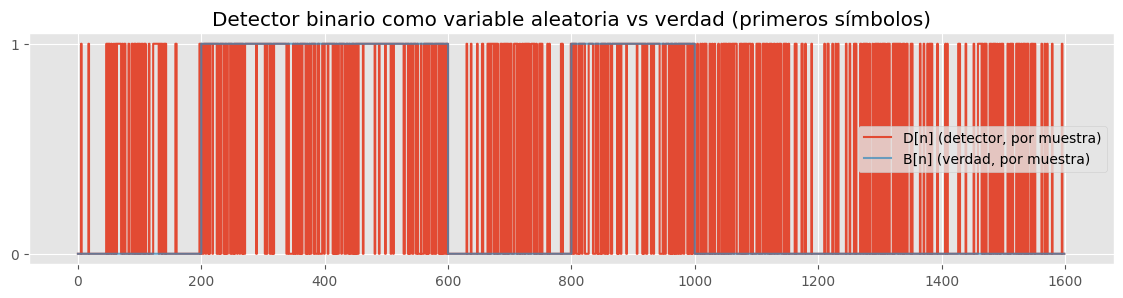

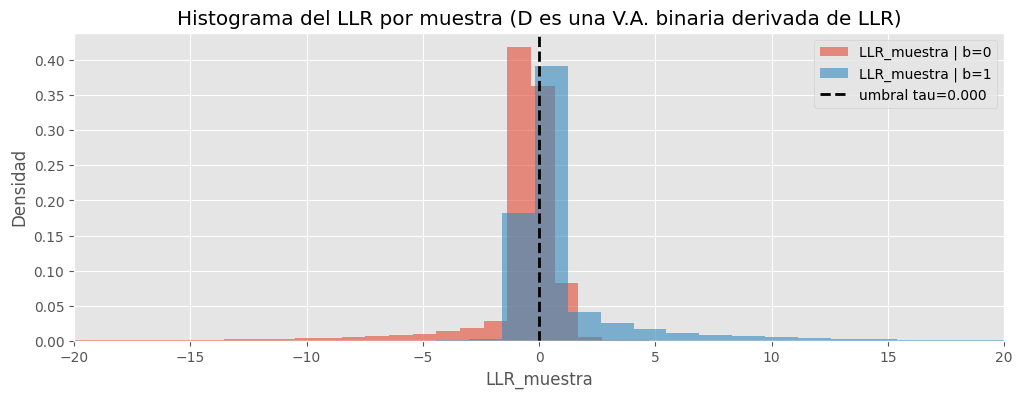

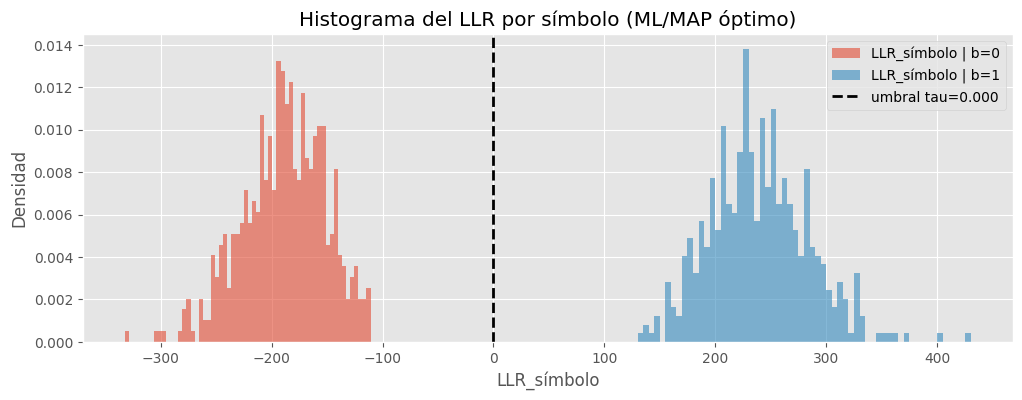


=== Resumen primeros símbolos ===
sym  0: b=0  maj=0  ML=0  p̂=0.260  LLR_sym=-206.82
sym  1: b=1  maj=1  ML=1  p̂=0.650  LLR_sym=280.76
sym  2: b=1  maj=1  ML=1  p̂=0.700  LLR_sym=205.16
sym  3: b=0  maj=0  ML=0  p̂=0.275  LLR_sym=-203.85
sym  4: b=1  maj=1  ML=1  p̂=0.665  LLR_sym=222.28
sym  5: b=0  maj=0  ML=0  p̂=0.340  LLR_sym=-203.35
sym  6: b=0  maj=0  ML=0  p̂=0.270  LLR_sym=-217.42
sym  7: b=0  maj=0  ML=0  p̂=0.260  LLR_sym=-159.57


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

# ============================================================
# REQUISITOS (DATOS REALES)
# ============================================================
req = ["rx_matrix", "bits", "sigma0_t", "sigma1_t", "noise_sigma"]
missing = [v for v in req if v not in globals()]
if missing:
    raise NameError(f"Faltan variables en tu notebook: {missing}. "
                    "Ejecuta primero las celdas donde se crean rx_matrix/bits y sigma0_t/sigma1_t/noise_sigma.")

Nsymbols, Ns = rx_matrix.shape
assert bits.shape[0] == Nsymbols, "bits debe tener longitud Nsymbols"
assert Nsymbols == 1024, "Se esperaban 1024 símbolos"

# ============================================================
# PARÁMETROS MAP (si no quieres MAP, deja priors/costos simétricos -> tau=0)
# ============================================================
p0, p1 = 0.5, 0.5
c00, c11 = 0.0, 0.0
c10, c01 = 1.0, 1.0

gamma = (p0 * (c10 - c00)) / (p1 * (c01 - c11))
tau = np.log(gamma)  # umbral MAP/ML sobre LLR (ML con priors/costos iguales -> tau=0)

print(f"tau = log(gamma) = {tau:.6f}  (ML puro => tau=0)")

# ============================================================
# 1) LLR POR MUESTRA (modelo correcto: media 0, varianzas distintas)
#    y[n]|Hi ~ N(0, sigma_i[n]^2 + noise_sigma^2)
# ============================================================
epsilon = 1e-6
sigma0_use = np.maximum(sigma0_t, epsilon)
sigma1_use = np.maximum(sigma1_t, epsilon)

sigma0_eff2 = sigma0_use**2 + noise_sigma**2  # (Ns,)
sigma1_eff2 = sigma1_use**2 + noise_sigma**2  # (Ns,)

const0 = -0.5 * np.log(2*np.pi*sigma0_eff2)    # (Ns,)
const1 = -0.5 * np.log(2*np.pi*sigma1_eff2)    # (Ns,)

# LLR_m[k,n] = log p(y_kn|H1) - log p(y_kn|H0)
LLR_m = (const1 - 0.5*(rx_matrix**2)/sigma1_eff2) - (const0 - 0.5*(rx_matrix**2)/sigma0_eff2)  # (Nsymbols,Ns)

# ============================================================
# 2) DETECTOR BINARIO COMO VARIABLE ALEATORIA (POR MUESTRA)
#    D_k[n] = 1{LLR_m[k,n] > tau}
# ============================================================
D_m = (LLR_m > tau).astype(int)  # (Nsymbols,Ns)

# "Verdad" por muestra: bit repetido Ns veces
B_m = np.repeat(bits, Ns).reshape(Nsymbols, Ns)

# Señales planas (si quieres verlas como proceso 1D)
D_flat = D_m.reshape(-1)
B_flat = B_m.reshape(-1)

# ============================================================
# 3) PROBABILIDADES EMPÍRICAS (TRATANDO D COMO V.A. BINARIA)
# ============================================================
Pe_samp = np.mean(D_flat != B_flat)
P_FA = np.mean(D_flat[B_flat == 0] == 1)   # P(D=1 | B=0)
P_M  = np.mean(D_flat[B_flat == 1] == 0)   # P(D=0 | B=1)
P_D  = np.mean(D_flat[B_flat == 1] == 1)   # P(D=1 | B=1)

P_D1 = np.mean(D_flat == 1)                # P(D=1) marginal
P_D0 = 1.0 - P_D1                          # P(D=0)

Ntest_samples = D_flat.size
se = np.sqrt(Pe_samp * (1 - Pe_samp) / Ntest_samples)
ci95 = (Pe_samp - 1.96*se, Pe_samp + 1.96*se)

print("\n=== Detector binario como V.A. (por muestra) ===")
print(f"P(D=1) = {P_D1:.6f}   P(D=0) = {P_D0:.6f}")
print(f"Pe_samp = {Pe_samp:.6f}")
print(f"P_FA    = {P_FA:.6f}   P_M = {P_M:.6f}   P_D = {P_D:.6f}")
print(f"IC95% Pe_samp ≈ [{ci95[0]:.6f}, {ci95[1]:.6f}]  (N={Ntest_samples})")

# ============================================================
# 4) DECISIÓN POR SÍMBOLO (dos enfoques)
# ============================================================
# (A) Mayoría sobre D_m
p_hat = D_m.mean(axis=1)                   # fracción de 1s dentro del símbolo
bits_hat_maj = (p_hat >= 0.5).astype(int)
Pe_maj = np.mean(bits_hat_maj != bits)

# (B) Óptimo ML/MAP por símbolo: sumar LLR y comparar con tau
LLR_sym = np.sum(LLR_m, axis=1)            # LLR del símbolo completo
bits_hat_ML = (LLR_sym > tau).astype(int)
Pe_ML = np.mean(bits_hat_ML != bits)

print("\n=== Decisión por símbolo ===")
print(f"Pe (mayoría sobre D_m) = {Pe_maj:.6f}")
print(f"Pe (ML/MAP óptimo con LLR_sym) = {Pe_ML:.6f}")

# ============================================================
# 5) VISUALIZACIONES (para entender D como proceso aleatorio)
# ============================================================
Nview = 8
L = Nview * Ns

plt.figure(figsize=(14,3))
plt.step(np.arange(L), D_flat[:L], where="post", label="D[n] (detector, por muestra)")
plt.step(np.arange(L), B_flat[:L], where="post", label="B[n] (verdad, por muestra)", alpha=0.7)
plt.yticks([0,1])
plt.title("Detector binario como variable aleatoria vs verdad (primeros símbolos)")
plt.grid(True)
plt.legend()
plt.show()

# Histograma LLR por muestra condicionado a clase (con cap para no graficar millones)
cap = 80000
LLR0 = LLR_m[bits == 0].ravel()
LLR1 = LLR_m[bits == 1].ravel()

rng_plot = np.random.default_rng(0)
if LLR0.size > cap: LLR0p = rng_plot.choice(LLR0, size=cap, replace=False)
else:              LLR0p = LLR0
if LLR1.size > cap: LLR1p = rng_plot.choice(LLR1, size=cap, replace=False)
else:              LLR1p = LLR1

plt.figure(figsize=(12,4))
plt.hist(LLR0p, bins=60, density=True, alpha=0.6, label="LLR_muestra | b=0")
plt.hist(LLR1p, bins=60, density=True, alpha=0.6, label="LLR_muestra | b=1")
plt.axvline(tau, color="k", linestyle="--", linewidth=2, label=f"umbral tau={tau:.3f}")
plt.title("Histograma del LLR por muestra (D es una V.A. binaria derivada de LLR)")
plt.xlabel("LLR_muestra")
plt.ylabel("Densidad")
plt.grid(True)
plt.legend()
plt.xlim(-20, 20)
plt.show()

# Histograma LLR por símbolo (diagnóstico más fuerte)
plt.figure(figsize=(12,4))
plt.hist(LLR_sym[bits == 0], bins=60, density=True, alpha=0.6, label="LLR_símbolo | b=0")
plt.hist(LLR_sym[bits == 1], bins=60, density=True, alpha=0.6, label="LLR_símbolo | b=1")
plt.axvline(tau, color="k", linestyle="--", linewidth=2, label=f"umbral tau={tau:.3f}")
plt.title("Histograma del LLR por símbolo (ML/MAP óptimo)")
plt.xlabel("LLR_símbolo")
plt.ylabel("Densidad")
plt.grid(True)
plt.legend()
plt.show()

print("\n=== Resumen primeros símbolos ===")
for k in range(min(Nview, Nsymbols)):
    print(f"sym {k:2d}: b={bits[k]}  maj={bits_hat_maj[k]}  ML={bits_hat_ML[k]}  p̂={p_hat[k]:.3f}  LLR_sym={LLR_sym[k]:.2f}")


#**Histograma por simbolo**


=== Detector por ENERGÍA (umbral thr_mid) ===
D0 (mediana Z|0) = 3.752507
D1 (mediana Z|1) = 4.950331
thr_mid=(D0+D1)/2 = 4.351419
TN=464, FP=68, FN=74, TP=418
Pfa=0.127820  Pd=0.849593  Pe=0.138672

=== Detector ML ÓPTIMO (LLR_sym > 0) ===
Umbral ML: 0
TN=532, FP=0, FN=0, TP=492
Pfa=0.000000  Pd=1.000000  Pe=0.000000


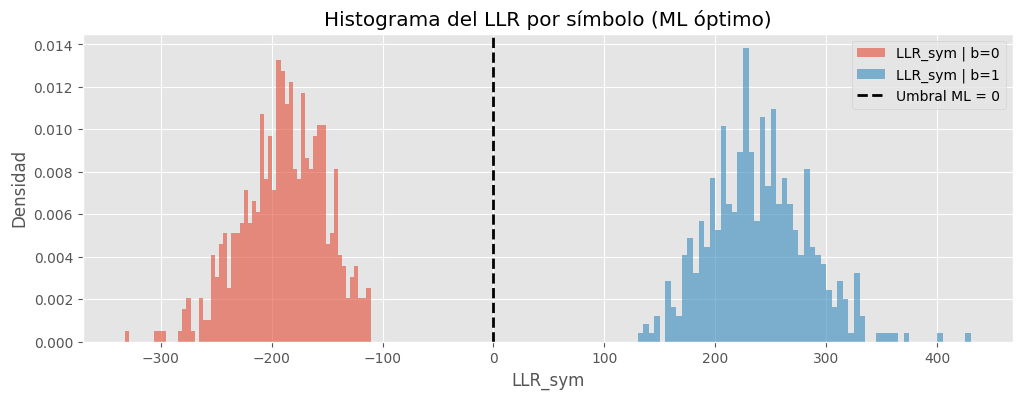

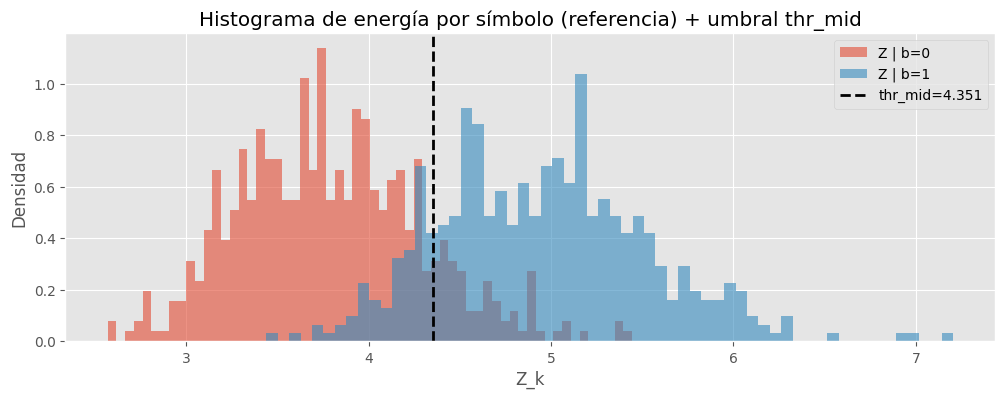

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

# ============================================================
# VALIDACIONES
# ============================================================
Nsymbols, Ns = rx_matrix.shape
assert bits.shape[0] == Nsymbols, "bits y rx_matrix deben tener el mismo número de símbolos"
assert Nsymbols == 1024, "Se esperaban 1024 símbolos"

epsilon = 1e-6  # piso numérico para evitar sigmas en 0 exacto

# Asegurar sigmas (std) por muestra
sigma0_use = np.maximum(sigma0_t, epsilon)  # (Ns,)
sigma1_use = np.maximum(sigma1_t, epsilon)  # (Ns,)
assert sigma0_use.shape[0] == Ns and sigma1_use.shape[0] == Ns

# ============================================================
# 1) DETECTOR POR ENERGÍA (REFERENCIA, NO ÓPTIMO)
# ============================================================
Z = np.mean(rx_matrix**2, axis=1)   # Z_k >= 0
Z0 = Z[bits == 0]
Z1 = Z[bits == 1]

D0 = np.median(Z0)
D1 = np.median(Z1)
thr_mid = 0.5 * (D0 + D1)

bits_hat_energy = (Z > thr_mid).astype(int)

# métricas
b0 = (bits == 0)
b1 = (bits == 1)

TN_e = np.sum((bits_hat_energy == 0) & b0)
FP_e = np.sum((bits_hat_energy == 1) & b0)
FN_e = np.sum((bits_hat_energy == 0) & b1)
TP_e = np.sum((bits_hat_energy == 1) & b1)

Pe_e  = np.mean(bits_hat_energy != bits)
Pfa_e = FP_e / max(np.sum(b0), 1)
Pd_e  = TP_e / max(np.sum(b1), 1)

# ============================================================
# 2) DETECTOR ÓPTIMO ML POR SÍMBOLO (LLR, MEDIA 0, VARIANZAS DIFERENTES)
#    y[n]|H_i ~ N(0, sigma_i[n]^2 + noise_sigma^2)
# ============================================================
sigma0_eff2 = sigma0_use**2 + noise_sigma**2   # (Ns,)
sigma1_eff2 = sigma1_use**2 + noise_sigma**2   # (Ns,)

const0 = -0.5 * np.log(2*np.pi*sigma0_eff2)    # (Ns,)
const1 = -0.5 * np.log(2*np.pi*sigma1_eff2)    # (Ns,)

# log-verosimilitudes por símbolo
logL0 = np.sum(const0 - 0.5*(rx_matrix**2)/sigma0_eff2, axis=1)  # (Nsymbols,)
logL1 = np.sum(const1 - 0.5*(rx_matrix**2)/sigma1_eff2, axis=1)  # (Nsymbols,)

LLR_sym = logL1 - logL0

# Regla ML (priors/costos iguales): umbral = 0
bits_hat_ML = (LLR_sym > 0).astype(int)

TN_m = np.sum((bits_hat_ML == 0) & b0)
FP_m = np.sum((bits_hat_ML == 1) & b0)
FN_m = np.sum((bits_hat_ML == 0) & b1)
TP_m = np.sum((bits_hat_ML == 1) & b1)

Pe_m  = np.mean(bits_hat_ML != bits)
Pfa_m = FP_m / max(np.sum(b0), 1)
Pd_m  = TP_m / max(np.sum(b1), 1)

# ============================================================
# 3) REPORTES
# ============================================================
print("\n=== Detector por ENERGÍA (umbral thr_mid) ===")
print(f"D0 (mediana Z|0) = {D0:.6f}")
print(f"D1 (mediana Z|1) = {D1:.6f}")
print(f"thr_mid=(D0+D1)/2 = {thr_mid:.6f}")
print(f"TN={TN_e}, FP={FP_e}, FN={FN_e}, TP={TP_e}")
print(f"Pfa={Pfa_e:.6f}  Pd={Pd_e:.6f}  Pe={Pe_e:.6f}")

print("\n=== Detector ML ÓPTIMO (LLR_sym > 0) ===")
print("Umbral ML: 0")
print(f"TN={TN_m}, FP={FP_m}, FN={FN_m}, TP={TP_m}")
print(f"Pfa={Pfa_m:.6f}  Pd={Pd_m:.6f}  Pe={Pe_m:.6f}")

# ============================================================
# 4) VISUALIZACIÓN CLAVE: HISTOGRAMA DE LLR POR CLASE
# ============================================================
LLR0 = LLR_sym[bits == 0]
LLR1 = LLR_sym[bits == 1]

plt.figure(figsize=(12,4))
plt.hist(LLR0, bins=60, density=True, alpha=0.6, label="LLR_sym | b=0")
plt.hist(LLR1, bins=60, density=True, alpha=0.6, label="LLR_sym | b=1")
plt.axvline(0.0, color="k", linestyle="--", linewidth=2, label="Umbral ML = 0")
plt.title("Histograma del LLR por símbolo (ML óptimo)")
plt.xlabel("LLR_sym")
plt.ylabel("Densidad")
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# 5) (Opcional) VISUALIZACIÓN: ENERGÍA POR CLASE + thr_mid
# ============================================================
plt.figure(figsize=(12,4))
plt.hist(Z0, bins=60, density=True, alpha=0.6, label="Z | b=0")
plt.hist(Z1, bins=60, density=True, alpha=0.6, label="Z | b=1")
plt.axvline(thr_mid, color="k", linestyle="--", linewidth=2, label=f"thr_mid={thr_mid:.3f}")
plt.title("Histograma de energía por símbolo (referencia) + umbral thr_mid")
plt.xlabel("Z_k")
plt.ylabel("Densidad")
plt.grid(True)
plt.legend()
plt.show()


#Histograma completo

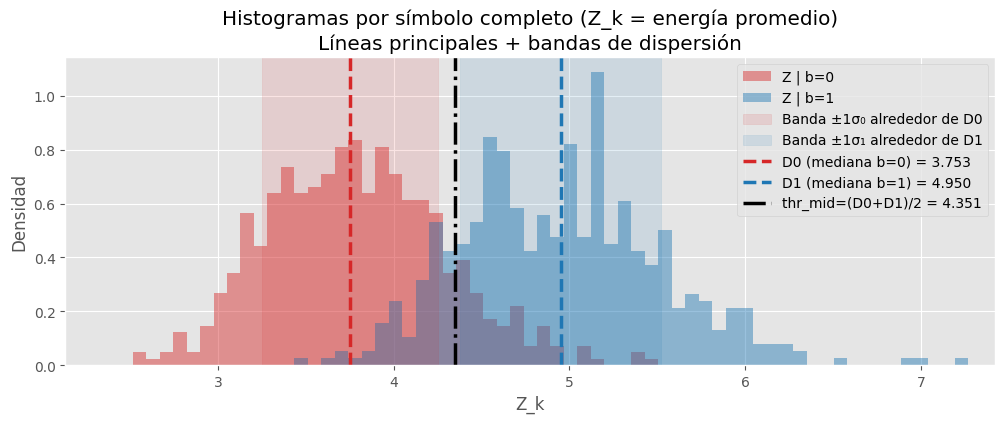

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

# ============================================================
# VALIDACIONES
# ============================================================
Nsymbols, Ns = rx_matrix.shape
assert Nsymbols == 1024
assert bits.shape[0] == 1024

# ============================================================
# 1) ESTADÍSTICO POR SÍMBOLO
# ============================================================
Z = np.mean(rx_matrix**2, axis=1)
Z0 = Z[bits == 0]
Z1 = Z[bits == 1]
assert Z0.size > 0 and Z1.size > 0

# ============================================================
# 2) MEDIANAS + DISPERSIÓN ALREDEDOR DE MEDIANA
# ============================================================
D0 = np.median(Z0)
D1 = np.median(Z1)

def sigma_about_median(x):
    x = np.asarray(x)
    n = x.size
    if n < 2:
        return np.nan
    m = np.median(x)
    return np.sqrt(np.sum((x - m)**2) / (n - 1))

sig0 = sigma_about_median(Z0)
sig1 = sigma_about_median(Z1)

thr_mid = 0.5*(D0 + D1)          # umbral intermedio (diagnóstico)
thr_user = 0.5*(D1 - D0)         # se calcula, pero puede no tener sentido físico en energía

# ============================================================
# 3) RANGO X MÁS AMPLIO (robusto + margen)
# ============================================================
Z_all = np.concatenate([Z0, Z1])

x_lo, x_hi = np.percentile(Z_all, [0.1, 99.9])  # más amplio que 0.5/99.5
x_lo = max(0.0, x_lo)                           # energía >= 0
xpad = 0.10 * (x_hi - x_lo)                     # margen 10%
x_min = max(0.0, x_lo - xpad)
x_max = x_hi + xpad

bins = np.linspace(x_min, x_max, 70)

# ============================================================
# 4) HISTOGRAMA + LÍNEAS COLOREADAS + BANDAS DE DISPERSIÓN
# ============================================================
fig, ax = plt.subplots(figsize=(12, 4))

# Colores explícitos (solicitado)
c0 = "tab:red"
c1 = "tab:blue"
ct = "black"

ax.hist(Z0, bins=bins, density=True, alpha=0.45, color=c0, label="Z | b=0")
ax.hist(Z1, bins=bins, density=True, alpha=0.45, color=c1, label="Z | b=1")

# Bandas ±1σ alrededor de la mediana (menos líneas, más claro)
ax.axvspan(max(0.0, D0 - sig0), D0 + sig0, color=c0, alpha=0.12, label="Banda ±1σ₀ alrededor de D0")
ax.axvspan(max(0.0, D1 - sig1), D1 + sig1, color=c1, alpha=0.12, label="Banda ±1σ₁ alrededor de D1")

# Líneas principales (pocas, pero muy informativas)
ax.axvline(D0, color=c0, linestyle="--", linewidth=2.5, label=f"D0 (mediana b=0) = {D0:.3f}")
ax.axvline(D1, color=c1, linestyle="--", linewidth=2.5, label=f"D1 (mediana b=1) = {D1:.3f}")
ax.axvline(thr_mid, color=ct, linestyle="-.", linewidth=2.5, label=f"thr_mid=(D0+D1)/2 = {thr_mid:.3f}")

# (Opcional) solo mostrar thr_user si cae dentro del rango visible
if x_min <= thr_user <= x_max:
    ax.axvline(thr_user, color="tab:gray", linestyle=":", linewidth=2.0,
               label=f"thr_user=(D0-D1)/2 = {thr_user:.3f}")

ax.set_title("Histogramas por símbolo completo (Z_k = energía promedio)\nLíneas principales + bandas de dispersión")
ax.set_xlabel("Z_k")
ax.set_ylabel("Densidad")
ax.set_xlim(x_min, x_max)
ax.grid(True)

# Leyenda más legible
ax.legend(loc="upper right", frameon=True, ncols=1)
plt.show()


#**#Detector Binario como señal aleatoria - probabilidad de error**


UMBRAL MAP (calibrado, KDE) = 37.868142

=== MAP (por muestra) en TEST ===
Pe_MAP = P(D != B)           = 0.451172
P_FA   = P(D=1 | B=0)        = 0.000000
P_M    = P(D=0 | B=1)        = 1.000000
IC 95% aprox para Pe_MAP     = [0.448124, 0.454220]  (N=102400)

=== MAP por símbolo (mayoría) en TEST ===
Pe_MAP_sym = P(b_hat != b)   = 0.451172

=== ML por símbolo (óptimo, modelo de varianza) en TEST ===
Pe_ML = P(b_hat != b)        = 0.000000


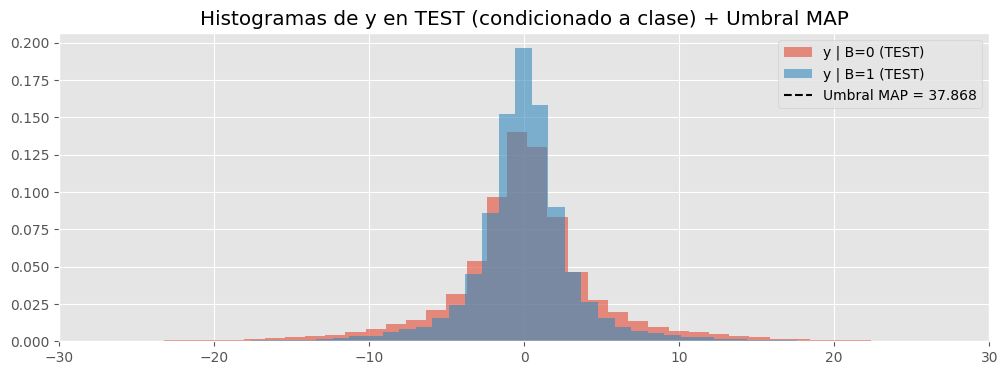

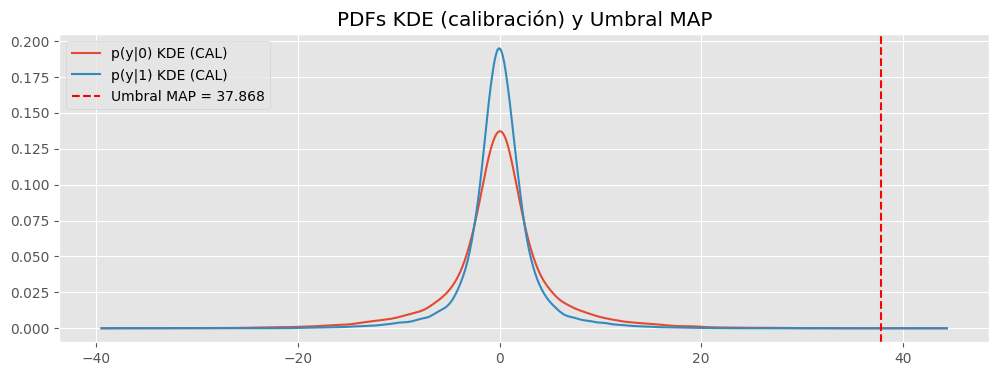

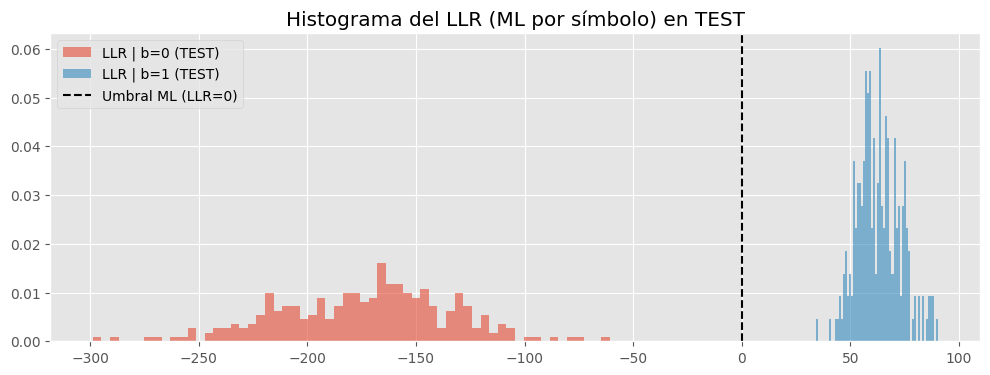

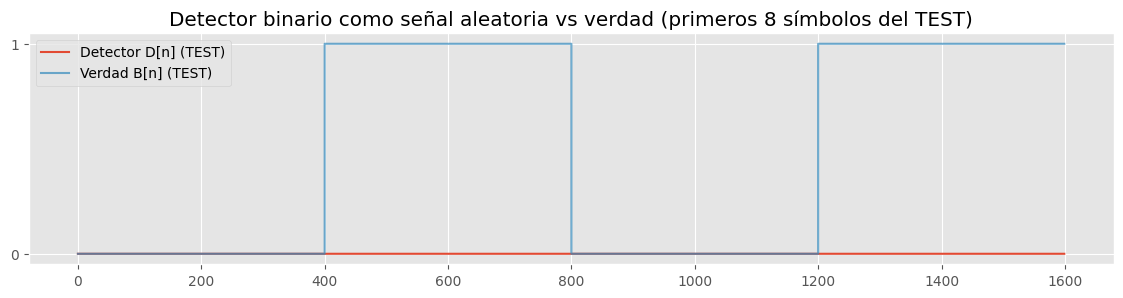


=== Resumen primeros 8 símbolos del TEST ===
sym  0: b=0  MAPmaj=0  ML=0  p̂=0.000  LLR=-210.87
sym  1: b=0  MAPmaj=0  ML=0  p̂=0.000  LLR=-135.19
sym  2: b=1  MAPmaj=0  ML=1  p̂=0.000  LLR=55.77
sym  3: b=1  MAPmaj=0  ML=1  p̂=0.000  LLR=52.70
sym  4: b=0  MAPmaj=0  ML=0  p̂=0.000  LLR=-93.59
sym  5: b=0  MAPmaj=0  ML=0  p̂=0.000  LLR=-188.20
sym  6: b=1  MAPmaj=0  ML=1  p̂=0.000  LLR=59.16
sym  7: b=1  MAPmaj=0  ML=1  p̂=0.000  LLR=48.39


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

plt.style.use("ggplot")

# ============================================================
# PARÁMETROS
# ============================================================
Nsymbols = 1024
Ns = 200
Nview = 8
noise_channel = 1.0
calib_frac = 0.5

# KDE grid
grid_points = 800

# Hist settings
hist_bins = 60
hist_sample_cap = 80000   # cap para no graficar millones de puntos si N crece

np.random.seed(None)

# ============================================================
# VARIANZAS POR MUESTRA (D0 montaña, D1 valle)
# ============================================================
def generar_varianzas(Ns, sigma0_max=3.0, sigma1_max=3.0):
    t = np.linspace(-1, 1, Ns)
    sigma_env = 0.35
    g = np.exp(-t*2 / (2*sigma_env*2))
    sigma0_t = sigma0_max * g
    sigma1_t = sigma1_max * (1 - g)
    return sigma0_t, sigma1_t

sigma0_t, sigma1_t = generar_varianzas(Ns)

def generar_simbolo(bit):
    if bit == 0:
        return np.random.randn(Ns) * sigma0_t
    else:
        return np.random.randn(Ns) * sigma1_t

# ============================================================
# 1) TRAMA + CANAL
# ============================================================
bits = np.random.randint(0, 2, Nsymbols)

tx_signal = np.zeros(Nsymbols * Ns)
for k, b in enumerate(bits):
    tx_signal[k*Ns:(k+1)*Ns] = generar_simbolo(b)

awgn = noise_channel * np.random.randn(Nsymbols * Ns)
rx_signal = tx_signal + awgn
rx_matrix = rx_signal.reshape(Nsymbols, Ns)

# ============================================================
# 2) SPLIT CALIB/TEST (sin fuga)
# ============================================================
idx_all = np.arange(Nsymbols)
np.random.shuffle(idx_all)

Ncal = int(calib_frac * Nsymbols)
idx_cal = idx_all[:Ncal]
idx_tst = idx_all[Ncal:]

rx_cal = rx_matrix[idx_cal]
rx_tst = rx_matrix[idx_tst]
bits_cal = bits[idx_cal]
bits_tst = bits[idx_tst]

# ============================================================
# 3) UMBRAL MAP (calibración) usando KDE sobre y (escala)
# ============================================================
y0_cal = rx_cal[bits_cal == 0].ravel()
y1_cal = rx_cal[bits_cal == 1].ravel()

if (y0_cal.size == 0) or (y1_cal.size == 0):
    raise RuntimeError("Calibración quedó con una clase vacía. Aumenta Nsymbols o ajusta calib_frac.")

kde0 = gaussian_kde(y0_cal)
kde1 = gaussian_kde(y1_cal)

xmin = min(y0_cal.min(), y1_cal.min())
xmax = max(y0_cal.max(), y1_cal.max())
xx = np.linspace(xmin, xmax, grid_points)

p0 = kde0(xx)
p1 = kde1(xx)

umbral = xx[np.argmin(np.abs(p1 - p0))]
print(f"\nUMBRAL MAP (calibrado, KDE) = {umbral:.6f}")

# ============================================================
# 4) DETECTOR BINARIO COMO SEÑAL ALEATORIA EN TEST (por muestra)
# ============================================================
rx_tst_flat = rx_tst.ravel()
B_tst_flat = np.repeat(bits_tst, Ns)                # verdad por muestra
D_tst_flat = (rx_tst_flat >= umbral).astype(int)    # señal aleatoria binaria

# ============================================================
# 5) PROBABILIDADES (NO SESGADAS) EN TEST
# ============================================================
Pe_MAP = np.mean(D_tst_flat != B_tst_flat)  # error por muestra
P_FA = np.mean(D_tst_flat[B_tst_flat == 0] == 1)    # P(D=1|0)
P_M  = np.mean(D_tst_flat[B_tst_flat == 1] == 0)    # P(D=0|1)

# Intervalo de confianza (aprox normal) para Pe_MAP
Ntest_samples = B_tst_flat.size
se = np.sqrt(Pe_MAP * (1 - Pe_MAP) / Ntest_samples)
ci95 = (Pe_MAP - 1.96*se, Pe_MAP + 1.96*se)

print("\n=== MAP (por muestra) en TEST ===")
print(f"Pe_MAP = P(D != B)           = {Pe_MAP:.6f}")
print(f"P_FA   = P(D=1 | B=0)        = {P_FA:.6f}")
print(f"P_M    = P(D=0 | B=1)        = {P_M:.6f}")
print(f"IC 95% aprox para Pe_MAP     = [{ci95[0]:.6f}, {ci95[1]:.6f}]  (N={Ntest_samples})")

# ============================================================
# 6) MAP POR SÍMBOLO (mayoría sobre la señal aleatoria)
# ============================================================
D_tst_matrix = D_tst_flat.reshape(len(idx_tst), Ns)
p_hat = D_tst_matrix.mean(axis=1)                   # fracción de 1s por símbolo
bits_hat_MAP_sym = (p_hat >= 0.5).astype(int)
Pe_MAP_sym = np.mean(bits_hat_MAP_sym != bits_tst)

print("\n=== MAP por símbolo (mayoría) en TEST ===")
print(f"Pe_MAP_sym = P(b_hat != b)   = {Pe_MAP_sym:.6f}")

# ============================================================
# 7) ML ÓPTIMO POR SÍMBOLO (sin KDE, usando varianzas reales)
#     y_{k,n} ~ N(0, sigma_b(n)^2 + sigma_c^2)
# ============================================================
sigma0_eff2 = sigma0_t**2 + noise_channel**2
sigma1_eff2 = sigma1_t**2 + noise_channel**2

const0 = -0.5 * np.log(2 * np.pi * sigma0_eff2)
const1 = -0.5 * np.log(2 * np.pi * sigma1_eff2)

logL0 = np.sum(const0 - 0.5 * (rx_tst**2) / sigma0_eff2, axis=1)
logL1 = np.sum(const1 - 0.5 * (rx_tst**2) / sigma1_eff2, axis=1)

LLR = logL1 - logL0
bits_hat_ML = (LLR > 0).astype(int)
Pe_ML = np.mean(bits_hat_ML != bits_tst)

print("\n=== ML por símbolo (óptimo, modelo de varianza) en TEST ===")
print(f"Pe_ML = P(b_hat != b)        = {Pe_ML:.6f}")

# ============================================================
# 8) HISTOGRAMAS / VISUALIZACIONES
# ============================================================

# --- (A) Histogramas de y en TEST condicionado a clase + umbral
y0_tst = rx_tst[bits_tst == 0].ravel()
y1_tst = rx_tst[bits_tst == 1].ravel()

# cap para graficar rápido si crece mucho
if y0_tst.size > hist_sample_cap:
    y0_plot = np.random.choice(y0_tst, size=hist_sample_cap, replace=False)
else:
    y0_plot = y0_tst
if y1_tst.size > hist_sample_cap:
    y1_plot = np.random.choice(y1_tst, size=hist_sample_cap, replace=False)
else:
    y1_plot = y1_tst

plt.figure(figsize=(12,4))
plt.hist(y0_plot, bins=hist_bins, density=True, alpha=0.6, label="y | B=0 (TEST)")
plt.hist(y1_plot, bins=hist_bins, density=True, alpha=0.6, label="y | B=1 (TEST)")
plt.axvline(umbral, color="k", linestyle="--", label=f"Umbral MAP = {umbral:.3f}")
plt.title("Histogramas de y en TEST (condicionado a clase) + Umbral MAP")
plt.grid(True)
plt.legend()
plt.xlim(-30, 30)
plt.show()

# --- (B) PDFs KDE de calibración + umbral
plt.figure(figsize=(12,4))
plt.plot(xx, p0, label="p(y|0) KDE (CAL)")
plt.plot(xx, p1, label="p(y|1) KDE (CAL)")
plt.axvline(umbral, color="red", linestyle="--", label=f"Umbral MAP = {umbral:.3f}")
plt.title("PDFs KDE (calibración) y Umbral MAP")
plt.grid(True)
plt.legend()
plt.show()

# --- (C) Histograma del estadístico ML (LLR) por clase + umbral 0
LLR0 = LLR[bits_tst == 0]
LLR1 = LLR[bits_tst == 1]

plt.figure(figsize=(12,4))
plt.hist(LLR0, bins=hist_bins, density=True, alpha=0.6, label="LLR | b=0 (TEST)")
plt.hist(LLR1, bins=hist_bins, density=True, alpha=0.6, label="LLR | b=1 (TEST)")
plt.axvline(0.0, color="k", linestyle="--", label="Umbral ML (LLR=0)")
plt.title("Histograma del LLR (ML por símbolo) en TEST")
plt.grid(True)
plt.legend()
plt.show()

# --- (E) Señal aleatoria del detector vs verdad (primeros 8 símbolos)
plt.figure(figsize=(14,3))
plt.step(np.arange(Nview*Ns), D_tst_flat[:Nview*Ns], where="post", label="Detector D[n] (TEST)")
plt.step(np.arange(Nview*Ns), B_tst_flat[:Nview*Ns], where="post", label="Verdad B[n] (TEST)", alpha=0.7)
plt.yticks([0,1])
plt.title("Detector binario como señal aleatoria vs verdad (primeros 8 símbolos del TEST)")
plt.grid(True)
plt.legend()
plt.show()

# --- (F) Resumen numérico de los primeros 8 símbolos en TEST
print("\n=== Resumen primeros 8 símbolos del TEST ===")
for k in range(min(Nview, len(bits_tst))):
    print(f"sym {k:2d}: b={bits_tst[k]}  MAPmaj={bits_hat_MAP_sym[k]}  ML={bits_hat_ML[k]}  p\u0302={p_hat[k]:.3f}  LLR={LLR[k]:.2f}")



=== Detector binario por muestra (LLR > 0) en TEST ===
tau_ML = 0.000
Pe_samp = 0.319434
P_FA    = 0.290760
P_M     = 0.349719
IC95% Pe = [0.316578, 0.322289]  (N=102400)

=== Decisión por símbolo en TEST ===
Pe (mayoría sobre D_muestra) = 0.000000
Pe (ML óptimo, sum LLR)      = 0.000000

(KDE diagnóstico) tau_kde donde p(LLR|0)≈p(LLR|1) = 74.725236 (debería estar cerca de 0 si el modelo cuadra)


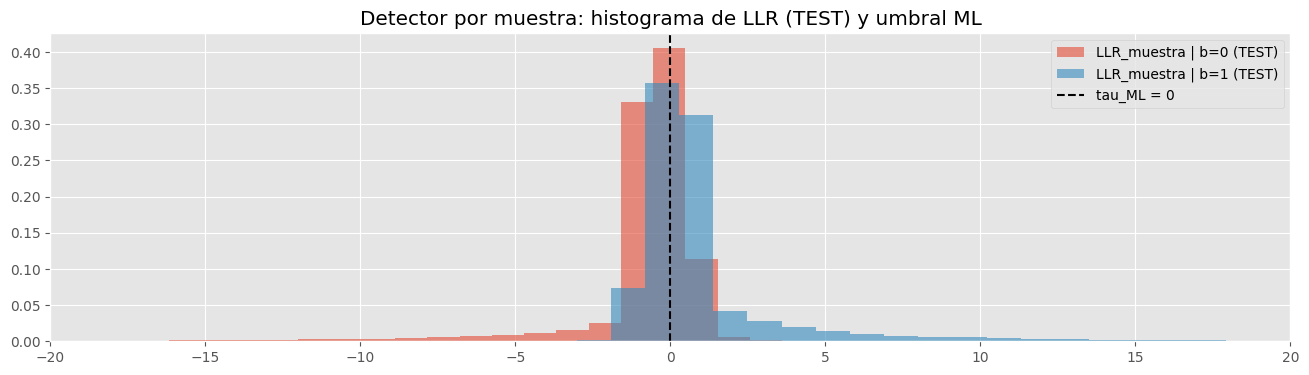

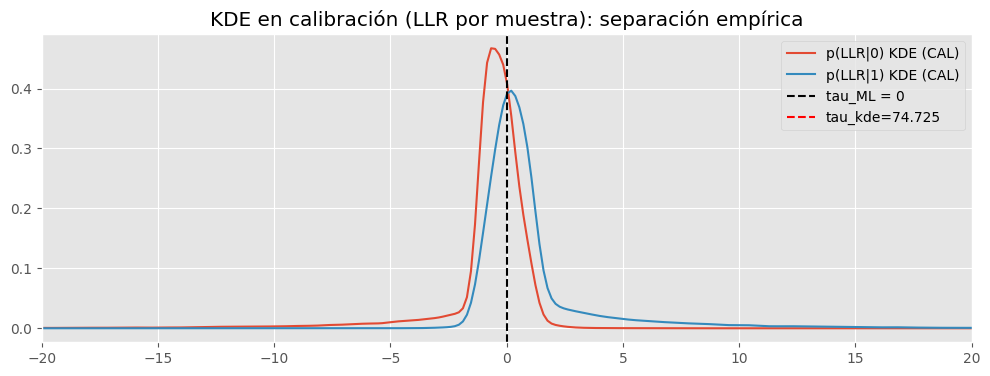

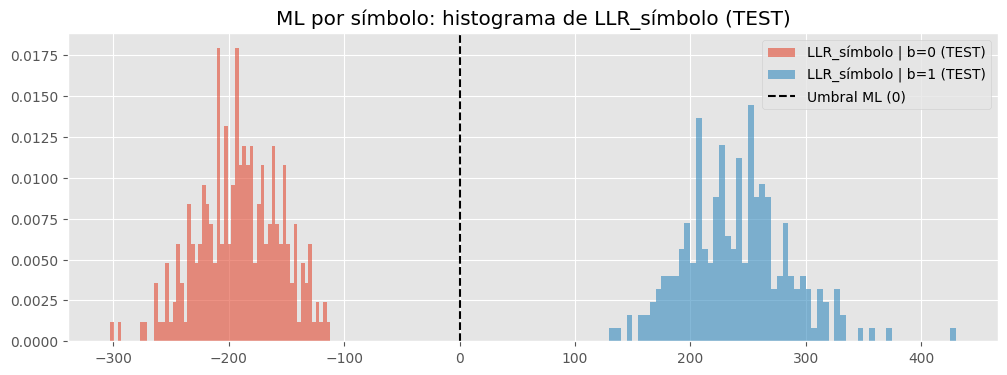

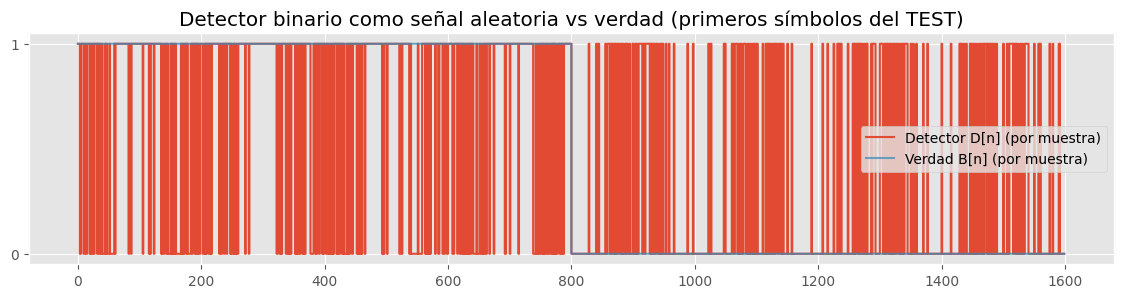


=== Resumen primeros símbolos del TEST ===
sym  0: b=1  maj=1  ML=1  p̂=0.615  LLR_sym=248.41
sym  1: b=1  maj=1  ML=1  p̂=0.740  LLR_sym=257.94
sym  2: b=1  maj=1  ML=1  p̂=0.665  LLR_sym=208.45
sym  3: b=1  maj=1  ML=1  p̂=0.670  LLR_sym=304.76
sym  4: b=0  maj=0  ML=0  p̂=0.315  LLR_sym=-128.75
sym  5: b=0  maj=0  ML=0  p̂=0.225  LLR_sym=-193.94
sym  6: b=0  maj=0  ML=0  p̂=0.300  LLR_sym=-141.18
sym  7: b=0  maj=0  ML=0  p̂=0.295  LLR_sym=-188.13


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

plt.style.use("ggplot")

# ============================================================
# PARÁMETROS
# ============================================================
Nsymbols = 1024
Ns = 200
Nview = 8

noise_sigma = 1.0      # sigma del AWGN del canal
calib_frac = 0.5       # fracción de símbolos para calibración

epsilon = 1e-6         # piso numérico para evitar sigma=0
sigma0_max = 3.0
sigma1_max = 3.0

# KDE grid
grid_points = 800

# Hist settings
hist_bins = 60
hist_sample_cap = 80000

assert Nview <= Nsymbols

# Reproducibilidad (pon seed=None si quieres corridas distintas)
seed = 123
rng = np.random.default_rng(seed)

# ============================================================
# SIGMAS POR MUESTRA (D0 "montaña", D1 "valle")  <-- CORREGIDO
# ============================================================
def generar_sigmas(Ns, sigma0_max=3.0, sigma1_max=3.0, sigma_env=0.35):
    t = np.linspace(-1, 1, Ns)
    g = np.exp(-(t**2) / (2 * sigma_env**2))     # <-- CORRECCIÓN: gaussiana real
    sigma0_t = sigma0_max * g
    sigma1_t = sigma1_max * (1 - g)
    return sigma0_t, sigma1_t

sigma0_t, sigma1_t = generar_sigmas(Ns, sigma0_max, sigma1_max)

# Piso numérico (evita zeros)
sigma0_use = np.maximum(sigma0_t, epsilon)
sigma1_use = np.maximum(sigma1_t, epsilon)

# ============================================================
# GENERACIÓN DE SÍMBOLO (media 0, sigma[k])
# ============================================================
def generar_simbolo(bit, rng):
    z = rng.standard_normal(Ns)  # N(0,1)
    if bit == 0:
        return z * sigma0_use
    else:
        return z * sigma1_use

# ============================================================
# 1) TRAMA + CANAL (EN MATRIZ: evita errores de reshape)
# ============================================================
bits = rng.integers(0, 2, Nsymbols)

tx_matrix = np.zeros((Nsymbols, Ns))
for k, b in enumerate(bits):
    tx_matrix[k, :] = generar_simbolo(int(b), rng)

awgn_matrix = noise_sigma * rng.standard_normal((Nsymbols, Ns))
rx_matrix = tx_matrix + awgn_matrix

# ============================================================
# 2) SPLIT CALIB/TEST (sin fuga, por símbolo)
# ============================================================
idx_all = np.arange(Nsymbols)
rng.shuffle(idx_all)

Ncal = int(calib_frac * Nsymbols)
idx_cal = idx_all[:Ncal]
idx_tst = idx_all[Ncal:]

rx_cal = rx_matrix[idx_cal]
rx_tst = rx_matrix[idx_tst]
bits_cal = bits[idx_cal]
bits_tst = bits[idx_tst]

if (np.sum(bits_cal == 0) == 0) or (np.sum(bits_cal == 1) == 0):
    raise RuntimeError("Calibración quedó con una clase vacía. Ajusta calib_frac o Nsymbols.")

# ============================================================
# 3) LLR POR MUESTRA (MODELO CORRECTO PARA VARIANZAS DIFERENTES)
#    y_k ~ N(0, sigma_eff^2[k]), sigma_eff^2[k] = sigma_b[k]^2 + noise_sigma^2
# ============================================================
sigma0_eff2 = sigma0_use**2 + noise_sigma**2    # shape: (Ns,)
sigma1_eff2 = sigma1_use**2 + noise_sigma**2

# log p(y|Hi) por muestra: const_i[k] - 0.5*y^2/sigma_i^2
const0 = -0.5 * np.log(2*np.pi*sigma0_eff2)
const1 = -0.5 * np.log(2*np.pi*sigma1_eff2)

def llr_por_muestra(y_matrix):
    # y_matrix: (Nsym, Ns)
    logp0 = const0 - 0.5 * (y_matrix**2) / sigma0_eff2
    logp1 = const1 - 0.5 * (y_matrix**2) / sigma1_eff2
    return logp1 - logp0  # (Nsym, Ns)

LLR_cal_m = llr_por_muestra(rx_cal)
LLR_tst_m = llr_por_muestra(rx_tst)

# ============================================================
# 4) DETECTOR BINARIO COMO VARIABLE ALEATORIA (POR MUESTRA)
#    ML (y MAP con priors/costos iguales): umbral tau = 0
# ============================================================
tau_ML = 0.0
D_tst_m = (LLR_tst_m > tau_ML).astype(int)   # (Nsym_test, Ns) -> señal aleatoria binaria por muestra

# verdad por muestra (bit repetido Ns veces)
B_tst_m = np.repeat(bits_tst, Ns).reshape(len(bits_tst), Ns)

# métricas por muestra
Pe_samp = np.mean(D_tst_m != B_tst_m)
P_FA = np.mean(D_tst_m[B_tst_m == 0] == 1)  # P(D=1|B=0)
P_M  = np.mean(D_tst_m[B_tst_m == 1] == 0)  # P(D=0|B=1)

Ntest_samples = B_tst_m.size
se = np.sqrt(Pe_samp * (1 - Pe_samp) / Ntest_samples)
ci95 = (Pe_samp - 1.96*se, Pe_samp + 1.96*se)

print("\n=== Detector binario por muestra (LLR > 0) en TEST ===")
print(f"tau_ML = {tau_ML:.3f}")
print(f"Pe_samp = {Pe_samp:.6f}")
print(f"P_FA    = {P_FA:.6f}")
print(f"P_M     = {P_M:.6f}")
print(f"IC95% Pe = [{ci95[0]:.6f}, {ci95[1]:.6f}]  (N={Ntest_samples})")

# ============================================================
# 5) DECISIÓN POR SÍMBOLO (dos maneras)
#    (A) Mayoría sobre D por muestra
#    (B) Óptimo ML por símbolo: sumar LLR del símbolo y comparar con 0
# ============================================================
# (A) mayoría
p_hat = D_tst_m.mean(axis=1)
bits_hat_maj = (p_hat >= 0.5).astype(int)
Pe_maj = np.mean(bits_hat_maj != bits_tst)

# (B) ML óptimo por símbolo
LLR_sym = np.sum(LLR_tst_m, axis=1)
bits_hat_ML = (LLR_sym > 0).astype(int)
Pe_ML = np.mean(bits_hat_ML != bits_tst)

print("\n=== Decisión por símbolo en TEST ===")
print(f"Pe (mayoría sobre D_muestra) = {Pe_maj:.6f}")
print(f"Pe (ML óptimo, sum LLR)      = {Pe_ML:.6f}")

# ============================================================
# 6) (Opcional) KDE SOLO PARA DIAGNÓSTICO: distribución de LLR por muestra
#    Esto NO reemplaza la regla ML (tau=0), solo muestra separación empírica.
# ============================================================
l0_cal = LLR_cal_m[bits_cal == 0].ravel()
l1_cal = LLR_cal_m[bits_cal == 1].ravel()

kde0 = gaussian_kde(l0_cal)
kde1 = gaussian_kde(l1_cal)

xmin = min(l0_cal.min(), l1_cal.min())
xmax = max(l0_cal.max(), l1_cal.max())
xx = np.linspace(xmin, xmax, grid_points)
p0 = kde0(xx)
p1 = kde1(xx)

tau_kde = xx[np.argmin(np.abs(p1 - p0))]
print(f"\n(KDE diagnóstico) tau_kde donde p(LLR|0)≈p(LLR|1) = {tau_kde:.6f} (debería estar cerca de 0 si el modelo cuadra)")

# ============================================================
# 7) VISUALIZACIONES
# ============================================================

# --- (A) Histograma de LLR por muestra (TEST) condicionado a clase + tau=0
l0_tst = LLR_tst_m[bits_tst == 0].ravel()
l1_tst = LLR_tst_m[bits_tst == 1].ravel()

# cap de puntos para graficar rápido
def cap_sample(x, cap, rng):
    if x.size > cap:
        return rng.choice(x, size=cap, replace=False)
    return x

l0_plot = cap_sample(l0_tst, hist_sample_cap, rng)
l1_plot = cap_sample(l1_tst, hist_sample_cap, rng)

plt.figure(figsize=(16,4))
plt.hist(l0_plot, bins=hist_bins, density=True, alpha=0.6, label="LLR_muestra | b=0 (TEST)")
plt.hist(l1_plot, bins=hist_bins, density=True, alpha=0.6, label="LLR_muestra | b=1 (TEST)")
plt.axvline(0.0, color="k", linestyle="--", label="tau_ML = 0")
plt.title("Detector por muestra: histograma de LLR (TEST) y umbral ML")
plt.grid(True)
plt.legend()
plt.xlim(-20, 20)
plt.show()

# --- (B) KDE de LLR en calibración (diagnóstico)
plt.figure(figsize=(12,4))
plt.plot(xx, p0, label="p(LLR|0) KDE (CAL)")
plt.plot(xx, p1, label="p(LLR|1) KDE (CAL)")
plt.axvline(0.0, color="k", linestyle="--", label="tau_ML = 0")
plt.axvline(tau_kde, color="red", linestyle="--", label=f"tau_kde={tau_kde:.3f}")
plt.title("KDE en calibración (LLR por muestra): separación empírica")
plt.grid(True)
plt.legend()
plt.xlim(-20, 20)
plt.show()

# --- (C) Histograma del LLR por símbolo (sumatoria) + umbral 0
LLR0_sym = LLR_sym[bits_tst == 0]
LLR1_sym = LLR_sym[bits_tst == 1]

plt.figure(figsize=(12,4))
plt.hist(LLR0_sym, bins=hist_bins, density=True, alpha=0.6, label="LLR_símbolo | b=0 (TEST)")
plt.hist(LLR1_sym, bins=hist_bins, density=True, alpha=0.6, label="LLR_símbolo | b=1 (TEST)")
plt.axvline(0.0, color="k", linestyle="--", label="Umbral ML (0)")
plt.title("ML por símbolo: histograma de LLR_símbolo (TEST)")
plt.grid(True)
plt.legend()
plt.show()

# --- (D) Señal aleatoria del detector por muestra vs verdad (primeros Nview símbolos del TEST)
D_flat = D_tst_m.reshape(-1)
B_flat = B_tst_m.reshape(-1)

plt.figure(figsize=(14,3))
plt.step(np.arange(Nview*Ns), D_flat[:Nview*Ns], where="post", label="Detector D[n] (por muestra)")
plt.step(np.arange(Nview*Ns), B_flat[:Nview*Ns], where="post", label="Verdad B[n] (por muestra)", alpha=0.7)
plt.yticks([0,1])
plt.title("Detector binario como señal aleatoria vs verdad (primeros símbolos del TEST)")
plt.grid(True)
plt.legend()
plt.show()

# --- (E) Resumen numérico primeros símbolos
print("\n=== Resumen primeros símbolos del TEST ===")
for k in range(min(Nview, len(bits_tst))):
    print(f"sym {k:2d}: b={bits_tst[k]}  maj={bits_hat_maj[k]}  ML={bits_hat_ML[k]}  p̂={p_hat[k]:.3f}  LLR_sym={LLR_sym[k]:.2f}")


#Detector euclídeo por símbolo (comparando distancia entre simbolos) - VARIABLE ALEATORIA

[Sanity] Fuente=tx_matrix | separación relativa por energía (medianas) = 0.1777
[Sanity] OK: bits y señal parecen consistentes. Uso tus datos actuales.

=== RESULTADOS DEFINITIVOS (ML) ===
Fuente usada: tx_matrix
Pe = 0.000000 | Pfa = 0.000000 | Pm = 0.000000


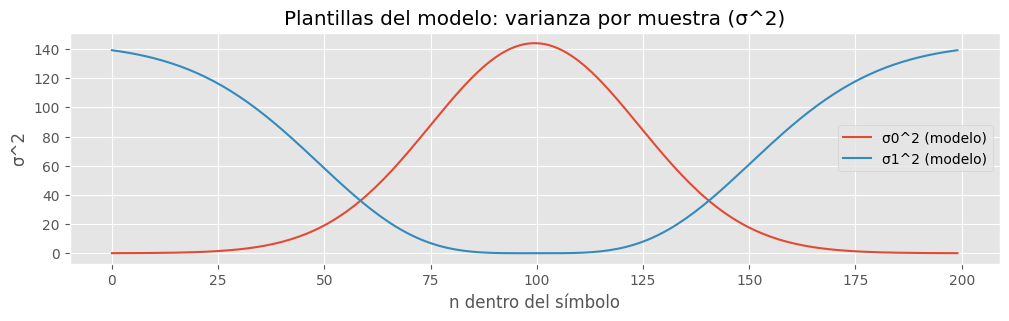

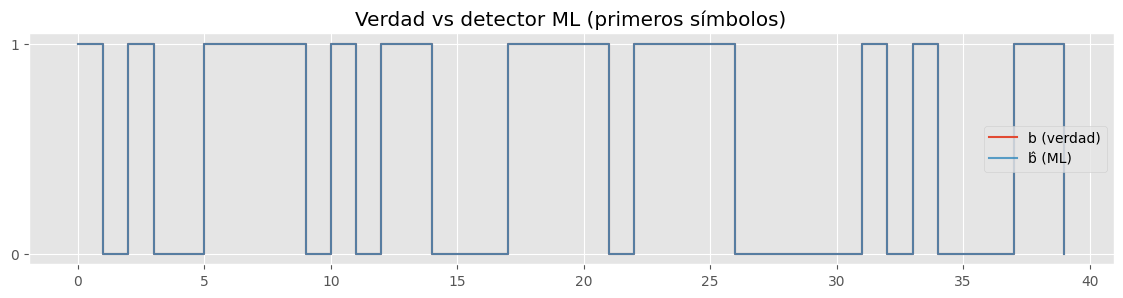

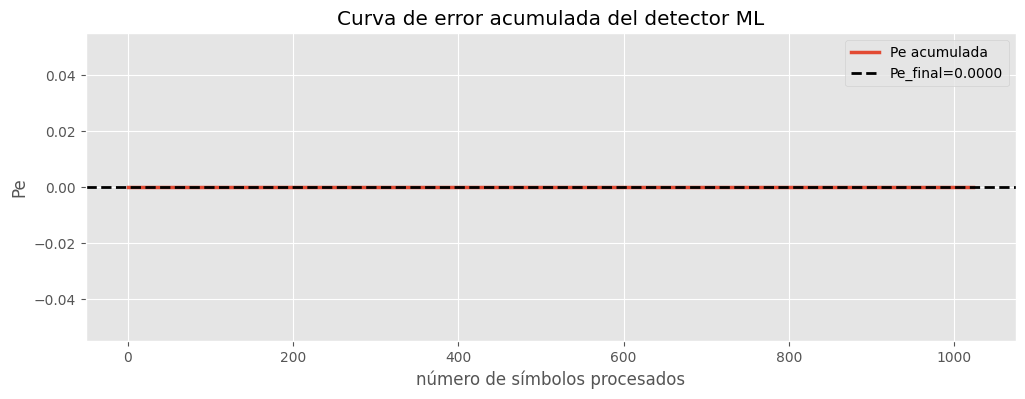

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

# ============================================================
# CONFIG
# ============================================================
FORCE_REBUILD = False   # ponlo True si quieres reconstruir sí o sí (recomendado si estás contra el tiempo)
Ns = 200
Nsymbols = 1024
sigma_max = 12.0
sigma_env = 0.35
epsilon = 1e-6
seed = 12345            # semilla fija -> todo consistente
noise_sigma = 0.0       # SIN AWGN (tal como pediste)

# ============================================================
# (A) SANITY CHECK: ¿bits y y_matrix corresponden?
# ============================================================
def sanity_check(bits, y_matrix):
    Z = np.mean(y_matrix**2, axis=1)  # energía promedio por símbolo
    Z0 = Z[bits==0]; Z1 = Z[bits==1]
    if len(Z0)==0 or len(Z1)==0:
        return False, np.nan
    # separación relativa robusta (medianas)
    D0 = np.median(Z0); D1 = np.median(Z1)
    sep = abs(D0-D1) / (abs(D0)+abs(D1)+1e-12)
    return (sep > 0.05), sep  # 0.05 es umbral razonable: si menor, parece mezcla/moneda

use_existing = False
sep_val = None
fuente = None

if not FORCE_REBUILD:
    if "bits" in globals() and (("tx_matrix" in globals()) or ("rx_matrix" in globals())):
        if "tx_matrix" in globals():
            y_matrix = tx_matrix
            fuente = "tx_matrix"
        else:
            y_matrix = rx_matrix
            fuente = "rx_matrix"

        ok, sep_val = sanity_check(bits, y_matrix)
        print(f"[Sanity] Fuente={fuente} | separación relativa por energía (medianas) = {sep_val:.4f}")
        if ok:
            use_existing = True
            Nsymbols, Ns = y_matrix.shape
            print("[Sanity] OK: bits y señal parecen consistentes. Uso tus datos actuales.")
        else:
            print("[Sanity] NO OK: separación ~0 => clases mezcladas o bits no corresponden a la señal. Reconstruyo todo consistente.")
    else:
        print("[Sanity] Faltan variables (bits y/o tx_matrix/rx_matrix). Reconstruyo todo consistente.")

# ============================================================
# (B) REBUILD CONSISTENTE (si hace falta)
# ============================================================
if not use_existing:
    rng = np.random.default_rng(seed)

    # envolventes de desviación estándar por muestra (modelo de tu cuaderno)
    t = np.linspace(-1, 1, Ns)
    g = np.exp(-(t**2) / (2*sigma_env**2))
    sigma0_t = sigma_max * g
    sigma1_t = sigma_max * (1 - g)

    sigma0_use = np.maximum(sigma0_t, epsilon)
    sigma1_use = np.maximum(sigma1_t, epsilon)

    bits = rng.integers(0, 2, Nsymbols)

    tx_matrix = np.zeros((Nsymbols, Ns))
    for k, b in enumerate(bits):
        w = rng.standard_normal(Ns)
        tx_matrix[k] = w * (sigma0_use if b==0 else sigma1_use)

    # canal AWGN NO aplicado (noise_sigma=0)
    rx_matrix = tx_matrix + noise_sigma * rng.standard_normal((Nsymbols, Ns))

    y_matrix = rx_matrix
    fuente = "REBUILD(rx_matrix)"

    ok, sep_val = sanity_check(bits, y_matrix)
    print(f"[Rebuild] Fuente={fuente} | separación relativa por energía (medianas) = {sep_val:.4f}")
    if not ok:
        raise RuntimeError("Incluso reconstruido, las clases no se separan (algo está mal en el modelo).")

# ============================================================
# DETECTOR DEFINITIVO: ML ÓPTIMO POR SÍMBOLO (media 0, varianza por muestra)
#   y[n]|Hi ~ N(0, sigma_i[n]^2 + noise_sigma^2)
# ============================================================
# Plantillas del modelo (con ruido de canal si existiera)
sig0_2 = np.maximum(sigma0_t**2 + noise_sigma**2, 1e-12)
sig1_2 = np.maximum(sigma1_t**2 + noise_sigma**2, 1e-12)

const0 = -0.5*np.log(2*np.pi*sig0_2)
const1 = -0.5*np.log(2*np.pi*sig1_2)

logL0 = np.sum(const0 - 0.5*(y_matrix**2)/sig0_2, axis=1)
logL1 = np.sum(const1 - 0.5*(y_matrix**2)/sig1_2, axis=1)

LLR = logL1 - logL0
bhat = (LLR > 0).astype(int)

err = (bhat != bits).astype(int)
Pe_final = float(np.mean(err))
Pe_curve = np.cumsum(err) / (np.arange(Nsymbols) + 1)

b0 = (bits==0); b1=(bits==1)
Pfa = float(np.mean(bhat[b0]==1)) if np.any(b0) else np.nan
Pm  = float(np.mean(bhat[b1]==0)) if np.any(b1) else np.nan

print("\n=== RESULTADOS DEFINITIVOS (ML) ===")
print(f"Fuente usada: {fuente}")
print(f"Pe = {Pe_final:.6f} | Pfa = {Pfa:.6f} | Pm = {Pm:.6f}")

# ============================================================
# GRÁFICAS MÍNIMAS, CLARAS (para examen)
# ============================================================

# 1) Plantillas sigma^2 (lo que diferencia 0 y 1)
plt.figure(figsize=(12,3))
plt.plot(sig0_2, label="σ0^2 (modelo)")
plt.plot(sig1_2, label="σ1^2 (modelo)")
plt.title("Plantillas del modelo: varianza por muestra (σ^2)")
plt.xlabel("n dentro del símbolo")
plt.ylabel("σ^2")
plt.grid(True)
plt.legend()
plt.show()

# 2) Bits reales vs detectados (primeros 40)
L = 40
plt.figure(figsize=(14,3))
plt.step(np.arange(L), bits[:L], where="post", label="b (verdad)")
plt.step(np.arange(L), bhat[:L], where="post", label="b̂ (ML)", alpha=0.8)
plt.yticks([0,1])
plt.title("Verdad vs detector ML (primeros símbolos)")
plt.grid(True)
plt.legend()
plt.show()

# 3) Curva de error acumulada
plt.figure(figsize=(12,4))
plt.plot(Pe_curve, linewidth=2.5, label="Pe acumulada")
plt.axhline(Pe_final, color="k", linestyle="--", linewidth=2, label=f"Pe_final={Pe_final:.4f}")
plt.title("Curva de error acumulada del detector ML")
plt.xlabel("número de símbolos procesados")
plt.ylabel("Pe")
plt.grid(True)
plt.legend()
plt.show()


Pe (solo distancia en energía, para explicación) = 0.000000


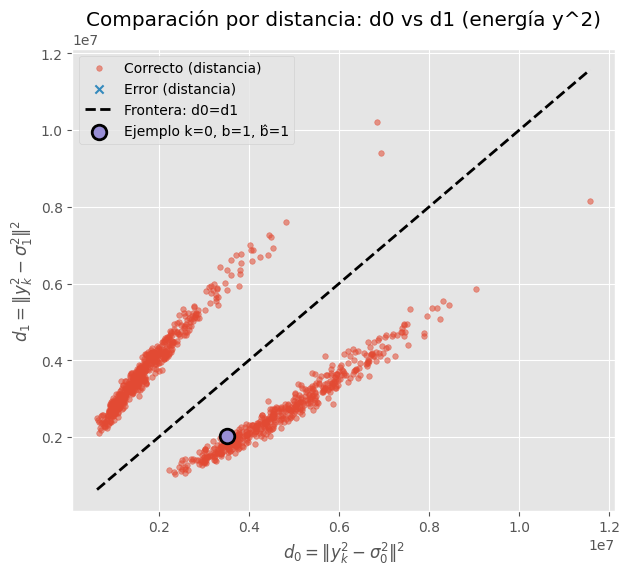

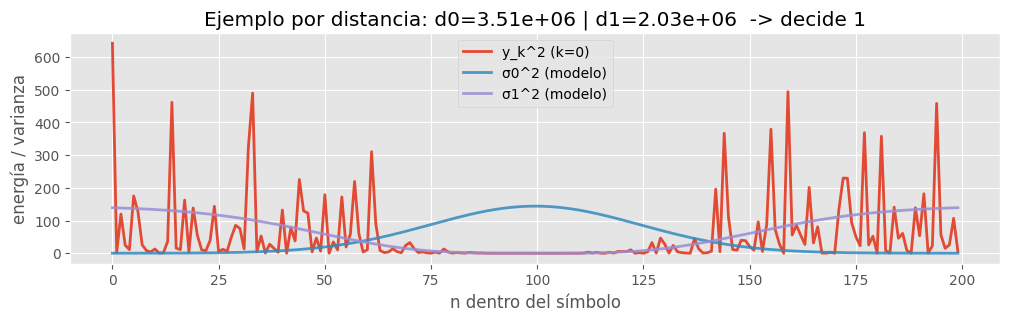

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

# Requiere que ya existan: y_matrix, bits, sig0_2, sig1_2
for v in ["y_matrix", "bits", "sig0_2", "sig1_2"]:
    if v not in globals():
        raise NameError(f"Falta '{v}'. Ejecuta primero la celda definitiva ML.")

# ============================================================
# 1) Distancias euclídeas en espacio de energía (y^2) contra plantillas σ^2
#    d0(k)=||y_k^2 - σ0^2||^2 , d1(k)=||y_k^2 - σ1^2||^2
# ============================================================
U = (y_matrix.astype(float)**2)
d0_euc = np.sum((U - sig0_2)**2, axis=1)
d1_euc = np.sum((U - sig1_2)**2, axis=1)

# Predicción por distancia (solo para comparar/explicar)
bhat_dist = (d1_euc < d0_euc).astype(int)
Pe_dist = np.mean(bhat_dist != bits)
print(f"Pe (solo distancia en energía, para explicación) = {Pe_dist:.6f}")

# Elegir un ejemplo: primer error de ML si existe, si no el primer símbolo
if "err" in globals():  # err del ML si existe
    idx_err = np.where(err == 1)[0]
    k_ex = int(idx_err[0]) if idx_err.size else 0
else:
    k_ex = 0

# ============================================================
# 2) Gráfica principal (muy explicable): dispersión d0 vs d1
#    - Diagonal: d0=d1 es la frontera
#    - Debajo de diagonal: d1<d0 => decide 1
#    - Encima de diagonal: d0<d1 => decide 0
# ============================================================
plt.figure(figsize=(7,6))

ok = (bhat_dist == bits)
plt.scatter(d0_euc[ok], d1_euc[ok], s=16, alpha=0.55, label="Correcto (distancia)")
plt.scatter(d0_euc[~ok], d1_euc[~ok], s=35, marker="x", label="Error (distancia)")

mmin = min(d0_euc.min(), d1_euc.min())
mmax = max(d0_euc.max(), d1_euc.max())
plt.plot([mmin, mmax], [mmin, mmax], "k--", linewidth=2, label="Frontera: d0=d1")

plt.scatter([d0_euc[k_ex]], [d1_euc[k_ex]], s=110, edgecolor="k", linewidth=2,
            label=f"Ejemplo k={k_ex}, b={bits[k_ex]}, b̂={bhat_dist[k_ex]}")

plt.title("Comparación por distancia: d0 vs d1 (energía y^2)")
plt.xlabel(r"$d_0=\|y_k^2-\sigma_0^2\|^2$")
plt.ylabel(r"$d_1=\|y_k^2-\sigma_1^2\|^2$")
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# 3) Mini-gráfica del ejemplo (para exposición): y^2 vs σ0^2 y σ1^2
# ============================================================
plt.figure(figsize=(12,3))
plt.plot(U[k_ex], label=f"y_k^2 (k={k_ex})", linewidth=2)
plt.plot(sig0_2, label="σ0^2 (modelo)", linewidth=2, alpha=0.85)
plt.plot(sig1_2, label="σ1^2 (modelo)", linewidth=2, alpha=0.85)
plt.title(f"Ejemplo por distancia: d0={d0_euc[k_ex]:.2e} | d1={d1_euc[k_ex]:.2e}  -> decide {bhat_dist[k_ex]}")
plt.xlabel("n dentro del símbolo")
plt.ylabel("energía / varianza")
plt.grid(True)
plt.legend()
plt.show()


### Gráfica 1) Señal recibida segmentada en símbolos
**Título:** 1) Señal recibida (sin AWGN) segmentada en símbolos  
**Qué se está viendo:** una porción de la señal en “stream” (concatenada) para los primeros $N_{view}$ símbolos.  

**Cómo se construye** `y_matrix` tiene forma ($N_{symbols}$, $N_s$):  
Fila $k$ = símbolo $\mathbf{y}_k \in \mathbb{R}^{Ns}$  

El código hace:  
1. `stream = y_matrix.reshape(-1)` → convierte la matriz en una señal 1D concatenada.  
2. Grafica `stream[:Nview*Ns]` → solo los primeros $N_{view}$ símbolos.  

**Qué significan los elementos visuales** Las líneas verticales punteadas en $k \cdot N_s$ marcan el inicio de cada símbolo:  
* símbolo 0: muestras $0 \dots N_s-1$  
* símbolo 1: muestras $N_s \dots 2N_s-1$  
* etc.  

Los textos encima de cada bloque:  
* $b=...$ = el bit real transmitido para ese símbolo.  
* $\hat{b}=...$ = el bit detectado por el detector solo si ya empezó la detección.  

**Punto clave: por qué a veces no aparece $\hat{b}$ en los primeros símbolos** Porque esos símbolos iniciales se usan como preámbulo para construir las plantillas $\mathbf{a}_0$ y $\mathbf{a}_1$ con muy pocos ejemplos ($N_{ref\_per\_class}$). Hasta que no se construyen ambas plantillas, el detector no puede decidir con la regla euclídea.  

**Cómo explicarlo al profesor (frase corta)** “Estoy recibiendo una señal continua, pero en realidad está formada por bloques de longitud $N_s$. Cada bloque es un símbolo $\mathbf{y}_k$. Aquí muestro la segmentación y etiqueto la verdad y la decisión del detector.”  

---

### Gráfica 2) Comparación de un símbolo recibido con $\mathbf{a}_0$ y $\mathbf{a}_1$
**Título:** 2) Comparación por distancia: $d_0=..., d_1=... \rightarrow$ decide ...  
**Qué se está viendo:** un símbolo individual $\mathbf{y}_k$ (un vector de $N_s$ muestras) comparado contra las dos plantillas.  

**Qué curvas aparecen** * $y_k$ recibido (la señal que llegó para ese símbolo).  
* $a_0$ (plantilla símbolo 0) (referencia para el 0).  
* $a_1$ (plantilla símbolo 1) (referencia para el 1).  

**Qué significan $d_0$ y $d_1$** El detector calcula:  
$$d_0(k)=\|\mathbf{y}_k-\mathbf{a}_0\|_2^2=\sum_{n=1}^{Ns}(y_k[n]-a_0[n])^2$$  
$$d_1(k)=\|\mathbf{y}_k-\mathbf{a}_1\|_2^2=\sum_{n=1}^{Ns}(y_k[n]-a_1[n])^2$$  

Y decide:  
* Si $d_0 \le d_1 \Rightarrow$ decide 0  
* Si $d_1 < d_0 \Rightarrow$ decide 1  

**Cómo leer visualmente la decisión** * Si la curva $y_k$ “se pega” más a $a_0$ (menor diferencia punto a punto), típicamente $d_0$ será menor.  
* Si se parece más a $a_1$, $d_1$ será menor.  

**Interpretación fuerte:** La distancia euclídea al cuadrado es literalmente “cuánto error cuadrático total” hay entre el símbolo recibido y la plantilla.  

**Por qué el código elige el símbolo “ejemplo”** * Si hay errores, toma el primer símbolo erróneo para mostrar un caso “interesante”.  
* Si no hay errores, toma el primer símbolo detectado.  
Esto es útil para defender el método: si muestra un error, puedes explicar por qué falló; si no, muestras un caso típico.  

**Cómo explicarlo al profesor (frase corta)** “Para cada símbolo recibido $\mathbf{y}_k$, calculo dos distancias: a la plantilla del 0 y a la del 1. Me quedo con la mínima. Esto es exactamente el criterio de mínima distancia del canal gaussiano (en el modelo del documento).”  

---

### Gráfica 3) Verdad vs detector en bits (primeros símbolos detectados)
**Título:** 3) Decisión por símbolo: verdad vs detector (primeros símbolos detectados)  
**Qué se está viendo:** una comparación directa de bits reales vs bits detectados, pero ya no en amplitud, sino en decisiones 0/1.  

**Qué se grafica** * `bits_det`: bits reales solo del tramo detectado (después del preámbulo).  
* `bhat_det`: decisiones del detector en ese mismo tramo.  

Se usa `plt.step` porque:  
* el bit es una variable discreta,  
* cada símbolo produce una sola decisión.  

**Ojo con el eje X (esto es importante explicarlo)** El eje X no es el índice original $k$ del símbolo global. Es el índice “local” dentro del tramo detectado:  
* punto 0 en la gráfica = primer símbolo detectado después del preámbulo,  
* punto 1 = el siguiente, etc.  
Esto lo hace más limpio para explicar desempeño del detector, sin mezclarlo con los símbolos usados como referencia.  

**Cómo identificar errores** Donde $b$ y $\hat{b}$ no coinciden (una línea está en 0 y la otra en 1), ahí hay un error. Esta gráfica es ideal para decir: “aquí el detector falló en este símbolo”.  

**Cómo explicarlo al profesor (frase corta)** “Aquí se ve la salida del detector como una secuencia digital y la comparo con la secuencia real. Las discrepancias son errores de detección por símbolo.”  

---

### Gráfica 4) Curva de error acumulada
**Título:** 4) Curva de error acumulada (tramo detectado)  
**Qué se está viendo:** cómo evoluciona la estimación de la probabilidad de error a medida que procesas más símbolos.  

**Qué es exactamente $P_e(k)$ en esta gráfica** El código construye:  
$$P_e(k)=\frac{\#\{\text{errores entre los primeros } k+1 \text{ símbolos detectados}\}}{k+1}$$  

Esto es una estimación empírica (por frecuencia relativa) del error.  
* Al principio puede subir/bajar mucho (porque hay pocos símbolos y cada error pesa mucho).  
* Con más símbolos, tiende a estabilizarse alrededor de un valor.  

**Qué significa la línea horizontal punteada** Es $P_{e\_final}$, el error total del tramo detectado:  
$$Pe_{final}=\frac{\#\text{errores totales}}{N_{detectados}}$$  
La curva debería converger hacia esa línea.  

**Qué NO es esta gráfica (para que no haya confusión)** No es una curva tipo BER vs SNR. Es BER/$P_e$ vs número de símbolos procesados. Si quisieras la curva “de comunicaciones clásica” ($P_e$ vs nivel de ruido), entonces sí tendrías que barrer `noise_sigma` y repetir el experimento.  

**Cómo explicarlo al profesor (frase corta)** “Esto muestra el desempeño acumulado. A medida que llegan más símbolos, la estimación de $P_e$ se estabiliza en el error final.”  

---

### Lectura global para examen (muy defendible)
* **Gráfica 1:** “Cómo llega la señal y cómo la segmento en símbolos.”  
* **Gráfica 2:** “Cómo decido un símbolo: comparo con dos plantillas y elijo la mínima distancia.”  
* **Gráfica 3:** “La salida del detector (bits) comparada con la verdad.”  
* **Gráfica 4:** “El error acumulado, que converge al $P_e$ final.”

#**Detector euclídeo por símbolo (comparando distancia entre simbolos + Ruido AWGN Vs SNR) - PROCESO ALEATORIO**

Ps (promedio por muestra) = 53.845826


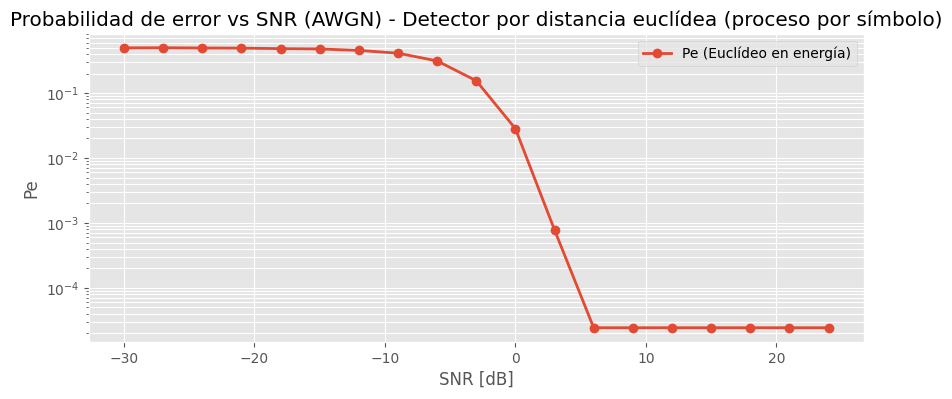

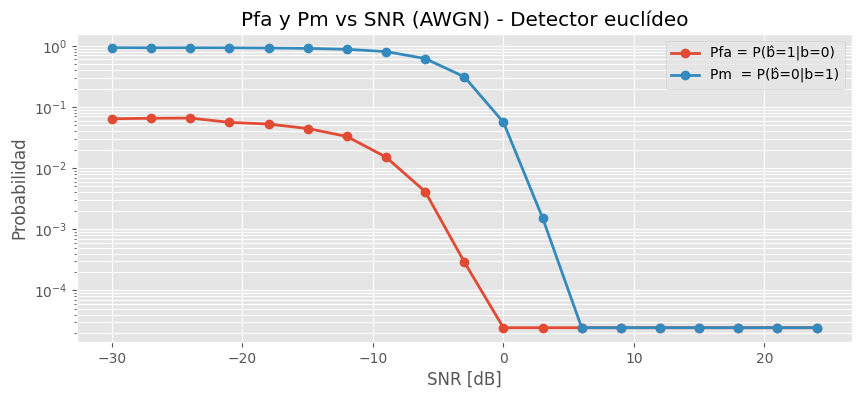

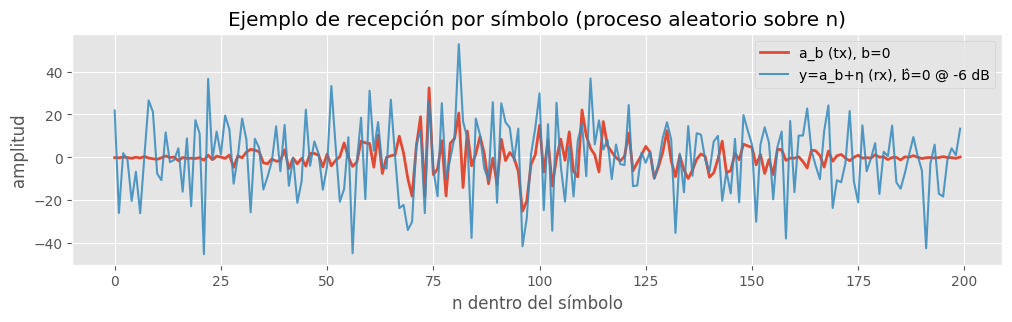


Notas:
- use_log_energy=True (si quieres, ponlo False para comparar).
- Piso de graficación en semilogy: Pe_floor=2.441e-05 (evita puntos 'perdidos' por Pe=0).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

# ============================================================
# CONFIG (ajustable)
# ============================================================
Ns = 200
Nsymbols = 1024

sigma_max = 12.0
sigma_env = 0.35
epsilon = 1e-6

seed = 2025
rng = np.random.default_rng(seed)

# SNR sweep (hazlo más amplio hacia abajo para ver la zona Pe~0.5)
SNR_dB = np.arange(-30, 26, 3)   # -30..25 dB cada 3 dB (curva completa y rápida)
n_trials = 20                    # promediado Monte Carlo (sube si quieres más suave)

# Mostrar un ejemplo a una SNR
snr_example_db = -6              # elige una zona donde se vea ruido (p.ej. -6, -10)

# Si quieres “dificultar” para que no caiga a 0 tan rápido, baja Ns o baja sigma_max.
# ============================================================

# ============================================================
# 1) Modelo de símbolos (proceso aleatorio en n dentro del símbolo)
#    a_b[n] = w[n] * sigma_b[n], w~N(0,1)
# ============================================================
t = np.linspace(-1, 1, Ns)
g = np.exp(-(t**2) / (2*sigma_env**2))

sigma0_t = sigma_max * g
sigma1_t = sigma_max * (1 - g)

sigma0_use = np.maximum(sigma0_t, epsilon)
sigma1_use = np.maximum(sigma1_t, epsilon)

# Potencia promedio "teórica/estable" por muestra (para definir SNR)
# E[a^2] = E[w^2]*E[sigma^2] = 1 * mean(sigma^2), con bits equiprobables:
Ps = 0.5 * (np.mean(sigma0_use**2) + np.mean(sigma1_use**2))
print(f"Ps (promedio por muestra) = {Ps:.6f}")

def generate_frame(rng):
    bits = rng.integers(0, 2, Nsymbols)
    W = rng.standard_normal((Nsymbols, Ns))
    tx = W * np.where(bits[:, None] == 0, sigma0_use[None, :], sigma1_use[None, :])
    return bits, tx

# ============================================================
# 2) Detector por distancia euclídea (mínima distancia) con AWGN
#    y = a_i + eta
#
# En energía: u = y^2
# Plantillas deterministas: t_i = sigma_i^2 + sigma_w^2
# d_i(k) = || u_k - t_i ||_2^2
# ============================================================
eps = 1e-12
use_log_energy = True  # recomendado para estabilidad (colas de chi-cuadrado)

def euclid_energy_detector(rx, noise_sigma):
    sigw2 = noise_sigma**2
    t0 = sigma0_use**2 + sigw2
    t1 = sigma1_use**2 + sigw2

    U = rx.astype(float)**2  # u_k[n] = y_k[n]^2

    if use_log_energy:
        Uc  = np.log(U  + eps)
        t0c = np.log(t0 + eps)
        t1c = np.log(t1 + eps)
    else:
        Uc, t0c, t1c = U, t0, t1

    d0 = np.sum((Uc - t0c)**2, axis=1)
    d1 = np.sum((Uc - t1c)**2, axis=1)

    bhat = (d1 < d0).astype(int)
    return bhat, d0, d1

# ============================================================
# 3) Barrido SNR -> Pe(SNR) (proceso aleatorio: regeneramos frame y ruido en cada trial)
# ============================================================
Pe  = np.zeros_like(SNR_dB, dtype=float)
Pfa = np.zeros_like(SNR_dB, dtype=float)
Pm  = np.zeros_like(SNR_dB, dtype=float)

# Piso para evitar ceros en semilogy:
# Si en Nt=Nsymbols*n_trials no hubo errores, Pe_hat=0, pero el límite resoluble ~ 1/Nt.
Pe_floor = 0.5 / (Nsymbols * n_trials)

for i, snr_db in enumerate(SNR_dB):
    snr_lin = 10**(snr_db/10)
    noise_var = Ps / snr_lin
    noise_sigma = np.sqrt(noise_var)

    pe_trials, pfa_trials, pm_trials = [], [], []

    for _ in range(n_trials):
        bits, tx = generate_frame(rng)
        noise = noise_sigma * rng.standard_normal(tx.shape)
        rx = tx + noise

        bhat, _, _ = euclid_energy_detector(rx, noise_sigma)

        err = (bhat != bits)
        pe_trials.append(np.mean(err))

        b0 = (bits == 0)
        b1 = (bits == 1)
        pfa_trials.append(np.mean(bhat[b0] == 1))
        pm_trials.append(np.mean(bhat[b1] == 0))

    Pe[i]  = float(np.mean(pe_trials))
    Pfa[i] = float(np.mean(pfa_trials))
    Pm[i]  = float(np.mean(pm_trials))

# Aplicar piso para graficar en semilogy sin perder puntos
Pe_plot  = np.maximum(Pe,  Pe_floor)
Pfa_plot = np.maximum(Pfa, Pe_floor)
Pm_plot  = np.maximum(Pm,  Pe_floor)

# ============================================================
# 4) Gráfica Pe vs SNR (completa)
# ============================================================
plt.figure(figsize=(10,4))
plt.semilogy(SNR_dB, Pe_plot, marker="o", linewidth=2, label="Pe (Euclídeo en energía)")
plt.title("Probabilidad de error vs SNR (AWGN) - Detector por distancia euclídea (proceso por símbolo)")
plt.xlabel("SNR [dB]")
plt.ylabel("Pe")
plt.grid(True, which="both")
plt.legend()
plt.show()

# ============================================================
# 5) (Opcional) Pfa y Pm vs SNR
# ============================================================
plt.figure(figsize=(10,4))
plt.semilogy(SNR_dB, Pfa_plot, marker="o", linewidth=2, label="Pfa = P(b̂=1|b=0)")
plt.semilogy(SNR_dB, Pm_plot,  marker="o", linewidth=2, label="Pm  = P(b̂=0|b=1)")
plt.title("Pfa y Pm vs SNR (AWGN) - Detector euclídeo")
plt.xlabel("SNR [dB]")
plt.ylabel("Probabilidad")
plt.grid(True, which="both")
plt.legend()
plt.show()

# ============================================================
# 6) Ejemplo de proceso aleatorio: un símbolo tx vs rx con ruido
# ============================================================
snr_ex_lin = 10**(snr_example_db/10)
noise_sigma_ex = np.sqrt(Ps / snr_ex_lin)

bits_ex, tx_ex = generate_frame(rng)
noise_ex = noise_sigma_ex * rng.standard_normal(tx_ex.shape)
rx_ex = tx_ex + noise_ex

bhat_ex, d0_ex, d1_ex = euclid_energy_detector(rx_ex, noise_sigma_ex)

k_ex = 0
plt.figure(figsize=(12,3))
plt.plot(tx_ex[k_ex], label=f"a_b (tx), b={bits_ex[k_ex]}", linewidth=2)
plt.plot(rx_ex[k_ex], label=f"y=a_b+η (rx), b̂={bhat_ex[k_ex]} @ {snr_example_db} dB", alpha=0.85)
plt.title("Ejemplo de recepción por símbolo (proceso aleatorio sobre n)")
plt.xlabel("n dentro del símbolo")
plt.ylabel("amplitud")
plt.grid(True)
plt.legend()
plt.show()

print("\nNotas:")
print(f"- use_log_energy={use_log_energy} (si quieres, ponlo False para comparar).")
print(f"- Piso de graficación en semilogy: Pe_floor={Pe_floor:.3e} (evita puntos 'perdidos' por Pe=0).")


# Detección binaria en AWGN con **proceso aleatorio** por símbolo (explicación de las gráficas)

## Contexto del experimento (qué se está simulando)
* Cada símbolo recibido es un **vector** de $N_s$ muestras:
  $$\mathbf{y}_k = [y_k[0],y_k[1],\dots,y_k[N_s-1]]$$
  Eso es un **proceso aleatorio discreto en n** (dentro del símbolo), no un único número.

* Canal AWGN:
  $$y_k[n] = a_{b_k}[n] + \eta_k[n],\qquad \eta_k[n]\sim\mathcal{N}(0,\sigma_w^2)$$
  El ruido afecta **cada muestra** del símbolo.

* Modelo de símbolos (como en tu cuaderno “montaña/valle”):
  * Media cero y **varianza dependiente de n**:
    $$a_{b}[n] = w[n]\;\sigma_b[n],\quad w[n]\sim \mathcal{N}(0,1)$$
  * Para $b=0$: $\sigma_0[n]$ (montaña); para $b=1$: $\sigma_1[n]$ (valle).

---

## Cómo decide el detector (distancia euclídea sobre energía)
Como aquí **no hay plantillas deterministas en amplitud** (la media de ambos símbolos es 0), la información discriminante está en la **energía por muestra**:
$$u_k[n]=y_k[n]^2$$

Las “plantillas” deterministas comparables son las energías esperadas:
* Con AWGN:
$$\mathbf{t}_0[n]=\sigma_0[n]^2+\sigma_w^2,\qquad \mathbf{t}_1[n]=\sigma_1[n]^2+\sigma_w^2$$

Distancias por símbolo:
$$d_0(k)=\|\mathbf{u}_k-\mathbf{t}_0\|_2^2,\qquad d_1(k)=\|\mathbf{u}_k-\mathbf{t}_1\|_2^2$$

Decisión:
* Si $d_0(k)\le d_1(k)\Rightarrow \hat b_k=0$
* Si $d_1(k)< d_0(k)\Rightarrow \hat b_k=1$

> **Nota:** en el código se usa **log-energía** $\log(u_k[n]+\epsilon)$ para estabilizar picos extremos, porque $y^2$ tiene colas grandes (chi-cuadrado).

---

# Gráfica 1: **Probabilidad de error vs SNR** ($P_e$ vs SNR)

### Qué muestra
* Eje X: **SNR en dB**.
* Eje Y: **$P_e$** (probabilidad de error) en escala logarítmica.
* Cada punto corresponde a una SNR; para esa SNR se hace Monte Carlo (`n_trials`) y se estima:
  $$P_e \approx \frac{\#\{\hat b_k\neq b_k\}}{N_{\text{símbolos}}}$$

### Cómo interpretarla
* **SNR baja**: el ruido domina $\Rightarrow P_e$ se acerca a $0.5$ (decisión casi aleatoria).
* **SNR alta**: el ruido es pequeño $\Rightarrow P_e$ baja rápidamente hacia 0.

### Por qué ahora la curva se ve “completa”
* En SNR altas puede ocurrir que no haya errores $\Rightarrow P_e=0$.
* En `semilogy` no se puede graficar 0 ($\log(0)$ no existe), y antes por eso “desaparecían” puntos.
* Se corrige usando un **piso estadístico**:
  $$P_{e,\min}\approx \frac{0.5}{N_{\text{símbolos}}\cdot n_{\text{trials}}}$$
  Esto NO inventa errores; solo evita que la escala logarítmica borre puntos.

---

# Gráfica 2: **$P_{FA}$ y $P_M$ vs SNR**

### Qué muestra
* Dos probabilidades condicionadas:
  * **Falsa alarma**:
    $$P_{FA}=P(\hat b=1\mid b=0)$$
  * **Omisión / Miss**:
    $$P_{M}=P(\hat b=0\mid b=1)$$

### Cómo interpretarla
* A SNR baja: ambas suben (más confusión).
* A SNR alta: ambas bajan (el detector separa bien las hipótesis).
* Si el sistema está balanceado (bits equiprobables y detector simétrico), típicamente:
  * $P_{FA}$ y $P_M$ son del mismo orden.
* Si una es mucho mayor que la otra, indica **sesgo** del detector hacia una clase (por ejemplo, decide “0” demasiado).

---

# Gráfica 3: **Ejemplo de recepción por símbolo** (proceso aleatorio)

### Qué muestra
* Un símbolo particular $k$ en el dominio de muestras dentro del símbolo.
* Dos curvas:
  * **Tx**: $a_b[n]$ (símbolo transmitido).
  * **Rx**: $y[n]=a_b[n]+\eta[n]$ (símbolo recibido).
* Se reporta la decisión $\hat b$ del detector para ese símbolo y la SNR seleccionada.

### Cómo interpretarla
* Aquí se ve físicamente el canal:
  * La señal recibida es la señal transmitida “perturbada” muestra a muestra por ruido gaussiano.
* Esta figura es la que justifica el término **proceso aleatorio**:
  * No es un solo valor aleatorio; es un conjunto de valores aleatorios $y[n]$ indexados por $n$.

---

## Relación con “variable aleatoria” vs “proceso aleatorio”
* **Variable aleatoria (caso anterior)**: trabajabas con un estadístico por símbolo, por ejemplo:
  $$Z_k=\frac{1}{N_s}\sum_{n}y_k[n]^2$$
  Eso es un solo número aleatorio por símbolo.

* **Proceso aleatorio (caso actual)**: el detector usa el vector completo:
  $$\mathbf{y}_k = \{y_k[n]\}_{n=0}^{N_s-1}$$
  y la decisión se hace con información de **todas las muestras** del símbolo.

---

## Resumen
“Para cada símbolo (un proceso aleatorio discreto de $N_s$ muestras) genero $y=a_i+\eta$, comparo su energía por muestra $y^2$ contra las plantillas $\sigma_0^2+\sigma_w^2$ y $\sigma_1^2+\sigma_w^2$ por distancia euclídea, y repito para varios SNR para obtener $P_e(\text{SNR})$, $P_{FA}(\text{SNR})$ y $P_M(\text{SNR})$.”

#**Detector Filtro Acoplado**

Usando a0/a1 existentes.
||a0||^2=1.550e+02, ||a1||^2=8.580e+01, Ps=0.601932

=== Resumen por SNR (conteos y probabilidades) ===
SNR[dB]   Ntot     Nerr      Pe        Pfa       Pm
 -15.0    61440     2312  0.037630  0.037253  0.038007
 -13.0    61440      804  0.013086  0.012701  0.013472
 -11.0    61440      183  0.002979  0.003343  0.002612
  -9.0    61440        6  0.000098  0.000129  0.000066
  -7.0    61440        1  0.000016  0.000000  0.000033
  -5.0    61440        0  0.000000  0.000000  0.000000
  -3.0    61440        0  0.000000  0.000000  0.000000
  -1.0    61440        0  0.000000  0.000000  0.000000
   1.0    61440        0  0.000000  0.000000  0.000000
   3.0    61440        0  0.000000  0.000000  0.000000
   5.0    61440        0  0.000000  0.000000  0.000000
   7.0    61440        0  0.000000  0.000000  0.000000
   9.0    61440        0  0.000000  0.000000  0.000000
  11.0    61440        0  0.000000  0.000000  0.000000
  13.0    61440        0  0.000000  0.000000  0.0

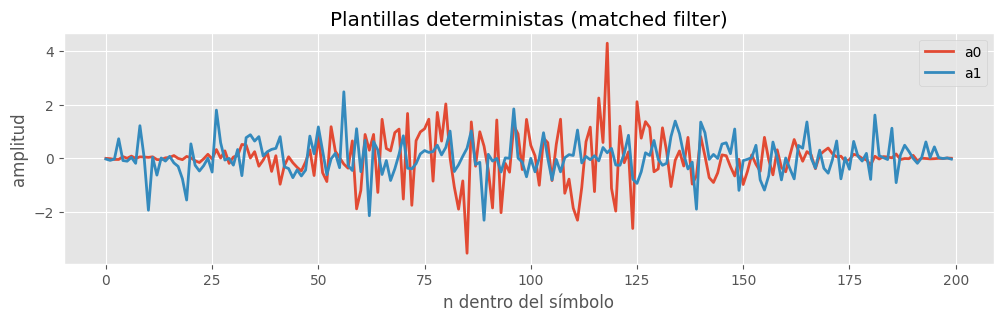

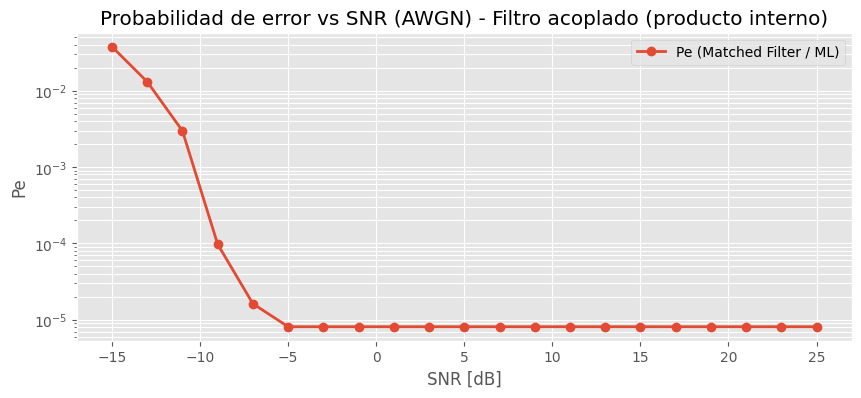

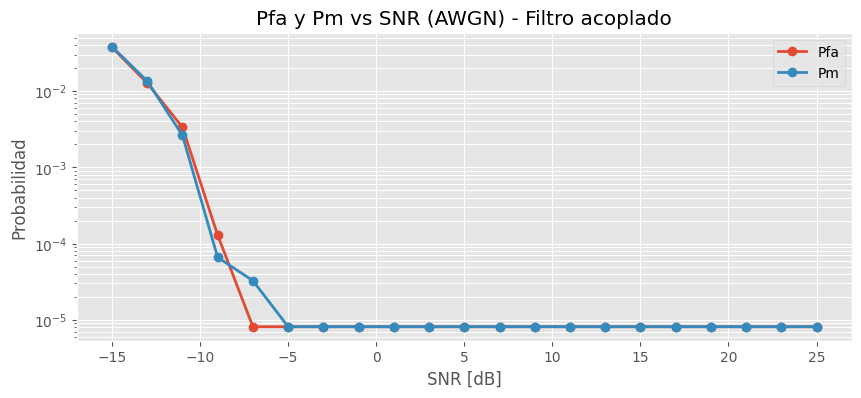

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

# ============================================================
# 0) CONFIGURACIÓN
# ============================================================
Ns = 200
Nsymbols = 2048
seed = 2025
rng = np.random.default_rng(seed)

SNR_dB = np.arange(-15, 26, 2)
n_trials = 30

Pe_floor = 0.5/(Nsymbols*n_trials)

# ============================================================
# 1) PLANTILLAS DETERMINISTAS a0, a1 (modelo clásico AWGN)
# ============================================================
if "a0" in globals() and "a1" in globals():
    a0 = np.asarray(a0, float).reshape(-1)
    a1 = np.asarray(a1, float).reshape(-1)
    if a0.size != Ns or a1.size != Ns:
        raise ValueError(f"a0/a1 deben tener longitud Ns={Ns}. Ahora: {a0.size}, {a1.size}")
    print("Usando a0/a1 existentes.")
else:
    sigma_max = 12.0
    sigma_env = 0.35
    t = np.linspace(-1, 1, Ns)
    g = np.exp(-(t**2)/(2*sigma_env**2))
    a0 = sigma_max * g
    a1 = sigma_max * (1 - g)
    print("Construyendo a0/a1 deterministas tipo montaña/valle.")

E0 = float(np.dot(a0, a0))
E1 = float(np.dot(a1, a1))
Ps = 0.5*(np.mean(a0**2) + np.mean(a1**2))

print(f"||a0||^2={E0:.3e}, ||a1||^2={E1:.3e}, Ps={Ps:.6f}")

# ============================================================
# 2) DETECTOR POR FILTRO ACOPLADO (producto interno)
#    ML en AWGN: score_i = <y,ai> - 0.5||ai||^2
# ============================================================
def matched_filter_detect(rx_matrix):
    z0 = rx_matrix @ a0
    z1 = rx_matrix @ a1
    s0 = z0 - 0.5*E0
    s1 = z1 - 0.5*E1
    bhat = (s1 > s0).astype(int)
    return bhat, z0, z1, s0, s1

# ============================================================
# 3) BARRIDO SNR: cálculo explícito de Pe, Pfa, Pm
# ============================================================
Pe  = np.zeros_like(SNR_dB, dtype=float)
Pfa = np.zeros_like(SNR_dB, dtype=float)
Pm  = np.zeros_like(SNR_dB, dtype=float)

print("\n=== Resumen por SNR (conteos y probabilidades) ===")
print("SNR[dB]   Ntot     Nerr      Pe        Pfa       Pm")

for i, snr_db in enumerate(SNR_dB):
    snr_lin = 10**(snr_db/10)
    noise_var = Ps / snr_lin
    noise_sigma = np.sqrt(noise_var)

    # Conteos acumulados (más “verídico” que promediar Pe por trial)
    Ntot = 0
    Nerr = 0
    N0 = 0; N1 = 0
    Nfa = 0; Nm = 0

    for _ in range(n_trials):
        bits = rng.integers(0, 2, Nsymbols)

        tx = np.where(bits[:, None] == 0, a0[None, :], a1[None, :])
        rx = tx + noise_sigma * rng.standard_normal(tx.shape)

        bhat, *_ = matched_filter_detect(rx)

        # === Cálculo de error: Pe = P(bhat != b) ===
        e = (bhat != bits)
        Nerr += int(np.sum(e))
        Ntot += bits.size

        # === Pfa y Pm ===
        mask0 = (bits == 0)
        mask1 = (bits == 1)
        N0 += int(np.sum(mask0))
        N1 += int(np.sum(mask1))
        Nfa += int(np.sum((bhat == 1) & mask0))  # bhat=1 cuando b=0
        Nm  += int(np.sum((bhat == 0) & mask1))  # bhat=0 cuando b=1

    Pe[i]  = Nerr / Ntot
    Pfa[i] = Nfa / N0 if N0 > 0 else np.nan
    Pm[i]  = Nm  / N1 if N1 > 0 else np.nan

    print(f"{snr_db:6.1f}  {Ntot:7d}  {Nerr:7d}  {Pe[i]:.6f}  {Pfa[i]:.6f}  {Pm[i]:.6f}")

# Piso para semilogy
Pe_plot = np.maximum(Pe, Pe_floor)

# ============================================================
# 4) GRÁFICAS
# ============================================================
plt.figure(figsize=(12,3))
plt.plot(a0, linewidth=2, label="a0")
plt.plot(a1, linewidth=2, label="a1")
plt.title("Plantillas deterministas (matched filter)")
plt.xlabel("n dentro del símbolo")
plt.ylabel("amplitud")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.semilogy(SNR_dB, Pe_plot, marker="o", linewidth=2, label="Pe (Matched Filter / ML)")
plt.title("Probabilidad de error vs SNR (AWGN) - Filtro acoplado (producto interno)")
plt.xlabel("SNR [dB]")
plt.ylabel("Pe")
plt.grid(True, which="both")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.semilogy(SNR_dB, np.maximum(Pfa, Pe_floor), marker="o", linewidth=2, label="Pfa")
plt.semilogy(SNR_dB, np.maximum(Pm,  Pe_floor), marker="o", linewidth=2, label="Pm")
plt.title("Pfa y Pm vs SNR (AWGN) - Filtro acoplado")
plt.xlabel("SNR [dB]")
plt.ylabel("Probabilidad")
plt.grid(True, which="both")
plt.legend()
plt.show()
